Enter category name (default 'Category'): Digital Literacy
Please upload TWO files: (1) Encoded dataset, (2) Key sheet.


Saving Digital_literacy_encoded_dataset.xlsx to Digital_literacy_encoded_dataset (1).xlsx
Saving Digital_literacy_key_sheet.xlsx to Digital_literacy_key_sheet (1).xlsx

✅ Encoded: Digital_literacy_encoded_dataset (1).xlsx
✅ Keysheet: Digital_literacy_key_sheet (1).xlsx
Category: Digital Literacy
=== FEATURE PREPARATION ===
Remaining numeric features: 22
- Dropped all-NaN: 0 | High-missing: 0 | Constants pre: 0 | post: 0


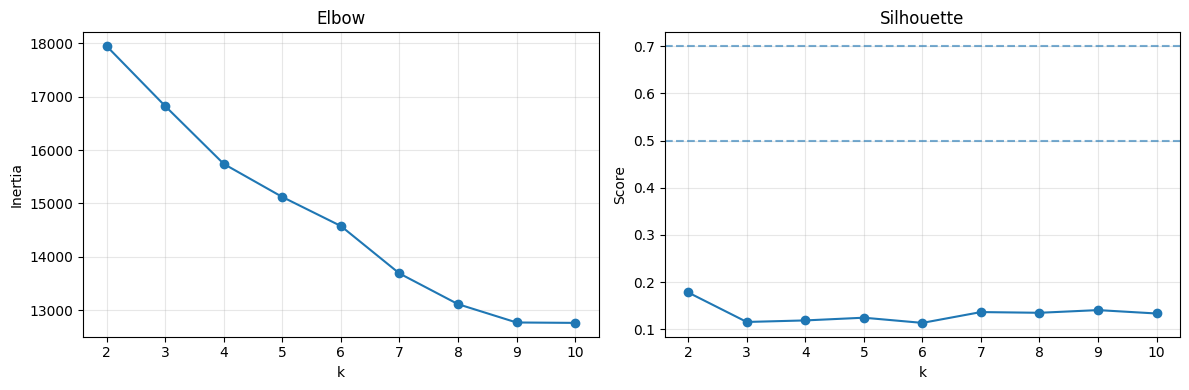

🎯 AUTO-SELECTED k = 2  (raw silhouette = 0.178, min cluster share = 40.5%, penalized score = 0.178)


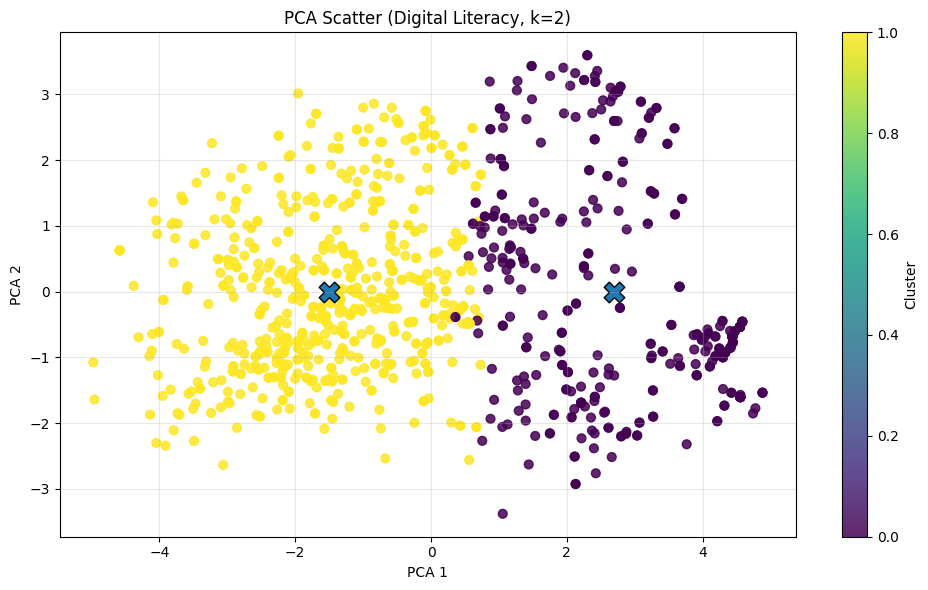

📊 DIGITAL LITERACY — CLUSTER PROFILING

👥 CLUSTER SIZES:
  Cluster 0: 359 (35.8%)
  Cluster 1: 643 (64.2%)

🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):
                                                                                           Feature       Score       p_value metric
                                                                                       W_03 [W_03] 1283.264801 1.772040e-181      F
                                                                                       W_04 [W_04]  818.099645 5.832678e-132      F
                                                                                       U_04 [U_04]  631.041540 2.370500e-108      F
                                                                                       U_05 [U_05]  570.032400 4.642710e-100      F
                                              How comfortable do you feel using digital tools? [Y]  519.238322  6.624865e-93      F
                                                          

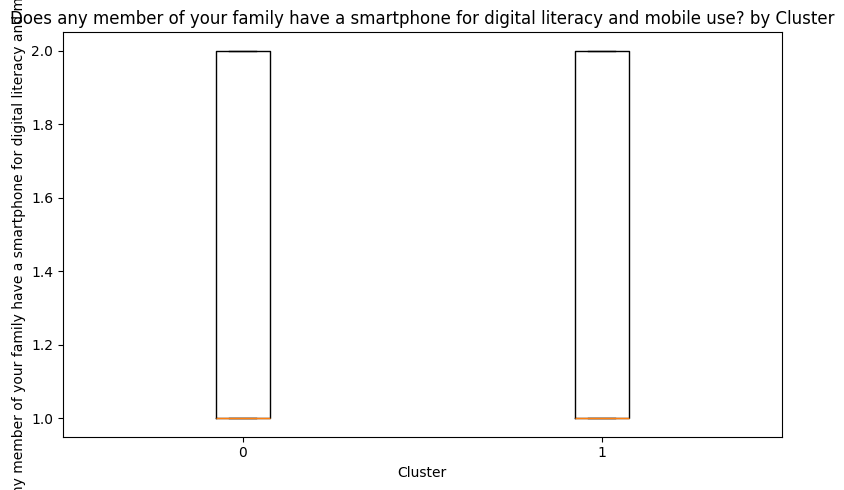

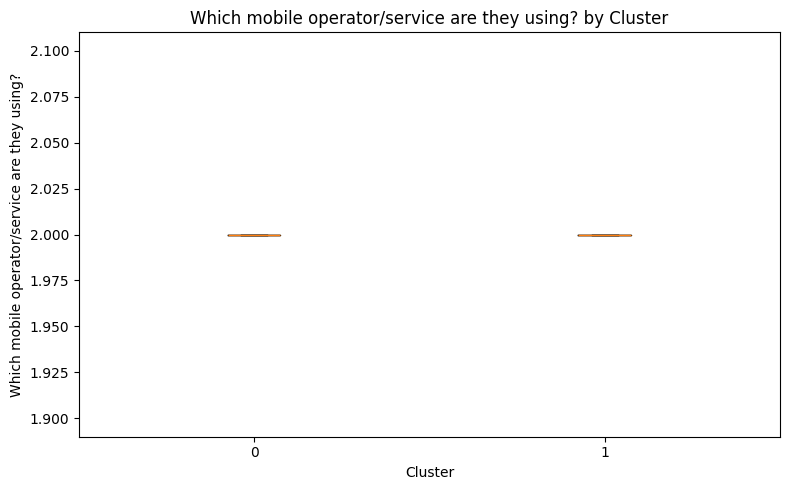

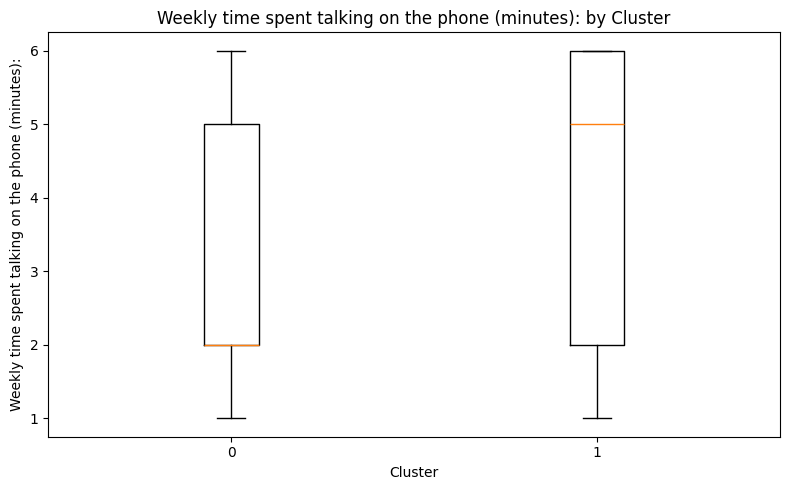

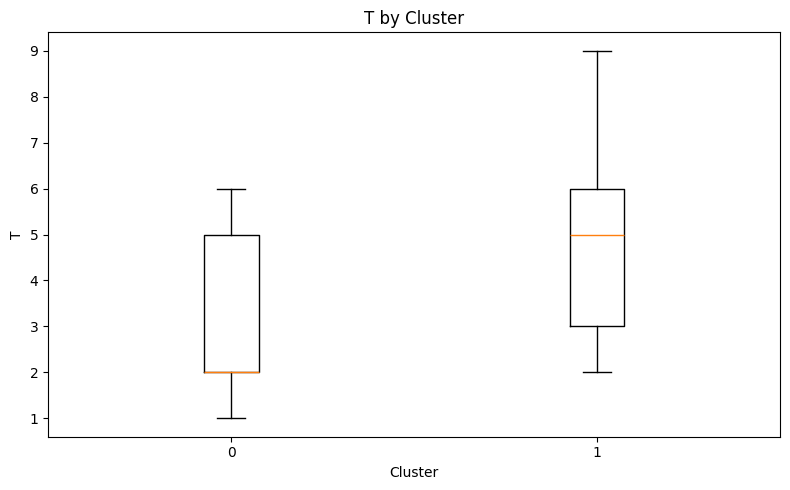

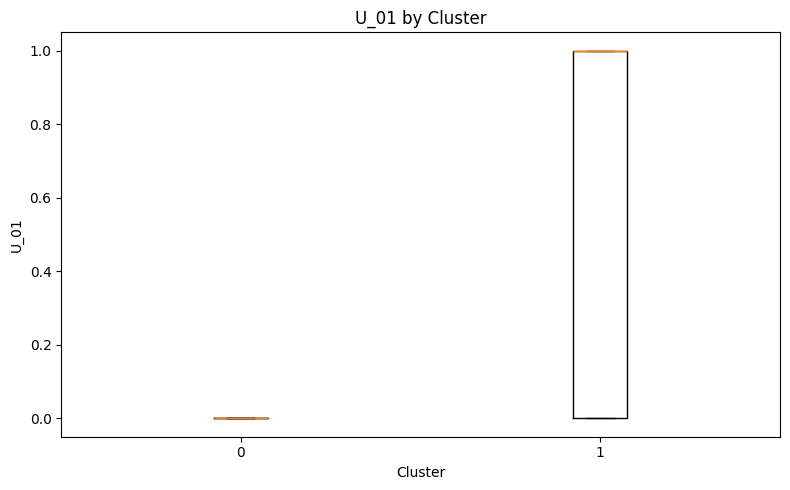

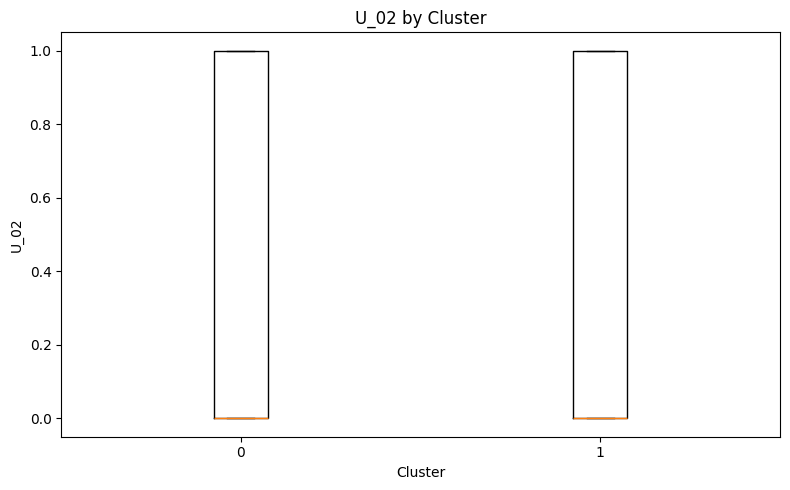

💡 DIGITAL LITERACY — BUSINESS INSIGHTS

📋 CLUSTER 0:
   no strong option-level deviations

📋 CLUSTER 1:
   no strong option-level deviations

📊 Average silhouette score: 0.184

Saved files:
 - clustered_output_Digital_Literacy.csv
 - anova_top_features_Digital_Literacy.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for both output files.


In [ ]:
# ============================================================
# Universal Category-wise Clustering & Profiling
# (Interactive upload, English labels, multi-answer aware)
# ============================================================

import os, io, re, math, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Tuple, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import f_classif, chi2

# -----------------------------
# CONFIG (edit if you like)
# -----------------------------
RANDOM_STATE = 42
K_RANGE = range(2, 11)
HIGH_MISSING_THRESH = 0.60

# k-selection guardrails (to avoid tiny, hard-to-interpret clusters)
MIN_CLUSTER_FRAC = 0.03   # reject k if any cluster <3% of samples
PREFER_K_MAX     = 6      # gently penalize k above this for interpretability

# Insights tuning
N_TOP_UP   = 3     # how many higher options to list per base
N_TOP_DOWN = 3     # how many lower options to list per base
EFFECT_PP  = 5.0   # only show lifts with |Δ| >= 5 percentage points

DEFAULT_CATEGORY_NAME = "Category"

# Bases you often want to protect from high-missing drop & narrate against (optional)
DEFAULT_PRIORITY_BASES = ["BR","BK","CE","CH","AB","Y","T"]


# ============================================================
# 0) INTERACTIVE UPLOADS (Colab OR Jupyter)
# ============================================================
def upload_two_excel_files():
    """Return (enc_bytes, key_bytes, enc_name, key_name) from an upload widget."""
    # Try Google Colab
    try:
        from google.colab import files  # type: ignore
        print("Please upload TWO files: (1) Encoded dataset, (2) Key sheet.")
        up = files.upload()
        if len(up) != 2:
            raise ValueError("Please upload exactly two files.")
        names = list(up.keys())
        enc_name, key_name = None, None
        enc_bytes, key_bytes = None, None
        for n in names:
            if "key" in n.lower() or "sheet" in n.lower():
                key_name, key_bytes = n, up[n]
            else:
                enc_name, enc_bytes = n, up[n]
        if not enc_bytes or not key_bytes:
            enc_name, enc_bytes = names[0], up[names[0]]
            key_name, key_bytes = names[1], up[names[1]]
        return io.BytesIO(enc_bytes), io.BytesIO(key_bytes), enc_name, key_name
    except Exception:
        pass

    # Jupyter widgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        up1 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload ENCODED .xlsx")
        up2 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload KEYSHEET .xlsx")
        btn = widgets.Button(description="Continue", button_style="primary")
        out = widgets.Output()
        display(up1, up2, btn, out)
        state = {"done": False, "enc": None, "key": None}
        def _on_click(b):
            with out:
                clear_output()
                if len(up1.value) != 1 or len(up2.value) != 1:
                    print("Please upload exactly one encoded file and one key sheet.")
                    return
                enc_item = list(up1.value.values())[0]
                key_item = list(up2.value.values())[0]
                state["enc"] = (io.BytesIO(enc_item["content"]), enc_item["metadata"]["name"])
                state["key"] = (io.BytesIO(key_item["content"]), key_item["metadata"]["name"])
                state["done"] = True
                print("Files captured. Proceeding…")
        btn.on_click(_on_click)
        while not state["done"]:
            time.sleep(0.2)
        (enc_bytes, enc_name) = state["enc"]
        (key_bytes, key_name) = state["key"]
        return enc_bytes, key_bytes, enc_name, key_name
    except Exception as e:
        raise RuntimeError("Upload widget not available. Please run in Colab/Jupyter.") from e


# ============================================================
# 1) MAPPING & MULTI-ANSWER LOGIC
# ============================================================
RAW_CODE_PAT      = re.compile(r"^([A-Z]+)(\d*)$")     # from raw headers: P, P1, P2…
RENAMED_CODE_PAT  = re.compile(r"\[([A-Z]+)(\d*)\]$")  # from renamed headers: … [P1]

def detect_bases_from_raw(df_raw: pd.DataFrame) -> Dict[str, List[str]]:
    bases = defaultdict(list)
    for c in df_raw.columns.astype(str):
        m = RAW_CODE_PAT.match(c)
        if m:
            bases[m.group(1)].append(c)
    return bases

def build_mapping(df_encoded: pd.DataFrame, key_df: pd.DataFrame) -> Dict[str, str]:
    encoded_cols = set(df_encoded.columns.astype(str))
    best_col, best_overlap = None, -1
    for col in key_df.columns:
        vals = key_df[col].astype(str).str.strip()
        # allow letters+digits in key sheet codes
        overlap = len(set(vals[vals.str.fullmatch(r"[A-Z]{1,3}\d*", na=False)]).intersection(encoded_cols))
        if overlap > best_overlap:
            best_col, best_overlap = col, overlap
    name_col = max([c for c in key_df.columns if c != best_col] or [key_df.columns[0]],
                   key=lambda c: key_df[c].astype(str).str.len().mean())
    mapping = {}
    for code, name in zip(
        key_df[best_col].astype(str).str.strip(),
        key_df[name_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ):
        if code in encoded_cols and name:
            mapping[code] = name
    return mapping

def rename_with_english_and_code(df_raw: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    new_cols = [f"{mapping.get(c,c)} [{c}]" for c in df_raw.columns.astype(str)]
    out = df_raw.copy()
    out.columns = new_cols
    return out

def group_by_base_after_rename(df_named: pd.DataFrame) -> Dict[str, List[str]]:
    by_base = defaultdict(list)
    for col in df_named.columns:
        m = RENAMED_CODE_PAT.search(col)
        if m:
            by_base[m.group(1)].append(col)
    return by_base

def english_stem_for_base(base: str, cols: List[str]) -> str:
    english_parts = [re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip() for c in cols]
    firsts = [p.split(":")[0].split("—")[0].strip() for p in english_parts]
    if len(set(firsts)) == 1:
        return firsts[0]
    return max(set(english_parts), key=english_parts.count) if english_parts else base

def prop(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(np.nanmean(s)) if s.size else np.nan


# ============================================================
# 2) FEATURE PREPARATION (numeric only; keep per-option binaries)
# ============================================================
def maybe_reduce_single_select(num_df: pd.DataFrame, by_base: Dict[str, List[str]],
                               threshold: float = 0.95) -> pd.DataFrame:
    """
    If a 'multi-answer' base is actually single-select (row sum == 1 in >= threshold of rows),
    drop the least prevalent option as a reference to reduce collinearity.
    """
    for b, cols in by_base.items():
        cols = [c for c in cols if c in num_df.columns]
        if len(cols) < 2:
            continue
        sums = num_df[cols].fillna(0).sum(axis=1)
        if (sums == 1).mean() >= threshold:
            prevalences = num_df[cols].mean().sort_values()
            drop_col = prevalences.index[0]
            num_df.drop(columns=[drop_col], inplace=True, errors="ignore")
    return num_df

def prepare_numeric(df_named: pd.DataFrame,
                    by_base: Dict[str, List[str]],
                    priority_bases: Optional[List[str]] = None,
                    high_missing_thresh: float = HIGH_MISSING_THRESH):
    num_df = df_named.select_dtypes(include=[np.number]).copy()
    num_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    all_nan_cols = num_df.columns[num_df.isna().all()].tolist()
    num_df.drop(columns=all_nan_cols, inplace=True, errors="ignore")

    priority_cols = set()
    if priority_bases:
        for b in priority_bases:
            for col in by_base.get(b, []):
                if col in num_df.columns:
                    priority_cols.add(col)

    miss = num_df.isna().mean()
    high_missing_cols = [c for c, m in miss.items() if (m > high_missing_thresh) and (c not in priority_cols)]
    num_df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

    # Optional: de-collinearize disguised single-selects
    num_df = maybe_reduce_single_select(num_df, by_base, threshold=0.95)

    # Drop constants (pre-impute)
    nunique = num_df.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    num_df.drop(columns=const_cols, inplace=True, errors="ignore")

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(num_df)

    # Drop constants AFTER impute (sometimes impute makes a column constant)
    _tmp = pd.DataFrame(X_imputed, columns=num_df.columns)
    const_after = _tmp.nunique(dropna=True)
    const_after_cols = const_after[const_after <= 1].index.tolist()
    if const_after_cols:
        num_df.drop(columns=const_after_cols, inplace=True, errors="ignore")
        X_imputed = SimpleImputer(strategy="median").fit_transform(num_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("=== FEATURE PREPARATION ===")
    print(f"Remaining numeric features: {num_df.shape[1]}")
    print(f"- Dropped all-NaN: {len(all_nan_cols)} | High-missing: {len(high_missing_cols)} "
          f"| Constants pre: {len(const_cols)} | post: {len(const_after_cols)}")

    return num_df, X_imputed, X_scaled


# ============================================================
# 3) k SELECTION with guardrails + FINAL CLUSTERING
# ============================================================
def choose_k_with_guards(X_scaled, k_range=K_RANGE, random_state=RANDOM_STATE,
                         min_cluster_frac=MIN_CLUSTER_FRAC, prefer_k_max=PREFER_K_MAX):
    inertia_list, sil_list, label_sets = [], [], []

    for k in k_range:
        mb = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init=5,
                             batch_size=256, max_iter=100, reassignment_ratio=0.01)
        labels_k = mb.fit_predict(X_scaled)
        label_sets.append(labels_k)
        inertia_list.append(mb.inertia_)
        sil_list.append(silhouette_score(X_scaled, labels_k))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(list(k_range), inertia_list, marker='o'); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.grid(True, alpha=0.3)
    ax2.plot(list(k_range), sil_list, marker='o'); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.5, linestyle='--', alpha=0.6); ax2.axhline(y=0.7, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # Penalize k with tiny clusters or too large k
    n = X_scaled.shape[0]
    candidates = []
    for k, sil, labels in zip(k_range, sil_list, label_sets):
        counts = np.bincount(labels)
        smallest_frac = counts.min() / n
        penalty = 0.0
        if k > prefer_k_max:       penalty += 0.02 * (k - prefer_k_max)   # gentle k penalty
        if smallest_frac < min_cluster_frac: penalty += 0.20              # strong tiny-cluster penalty
        candidates.append((k, sil - penalty, sil, smallest_frac))
    best_k, penalized, raw_sil, min_frac = max(candidates, key=lambda t: t[1])
    print(f"🎯 AUTO-SELECTED k = {best_k}  (raw silhouette = {raw_sil:.3f}, "
          f"min cluster share = {min_frac*100:.1f}%, penalized score = {penalized:.3f})")
    return best_k, inertia_list, sil_list

def run_kmeans(X_scaled, best_k, random_state=RANDOM_STATE):
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_scaled)
    return km, labels


# ============================================================
# 4) PCA + PROFILING (ANOVA/χ²) + INSIGHTS
# ============================================================
def plot_pca(X_scaled, labels, kmeans, category):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40, alpha=0.85)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=220, edgecolor='k')
    plt.title(f"PCA Scatter ({category}, k={kmeans.n_clusters})")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.colorbar(sc, label="Cluster"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return pca, X_pca, centroids_pca

def rank_features_discriminative(X_imp_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    # Try ANOVA F first
    try:
        F, p = f_classif(X_imp_df, labels)
        df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": F, "p_value": p, "metric": "F"})
        return df.replace([np.inf, -np.inf], np.nan)
    except Exception:
        pass
    # Fallback to chi-square (requires non-negative)
    X_nonneg = (X_imp_df - X_imp_df.min()).clip(lower=0.0)
    chi, p = chi2(X_nonneg, labels)
    df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": chi, "p_value": p, "metric": "chi2"})
    return df.replace([np.inf, -np.inf], np.nan)

def profile_clusters(category, df_named, num_df, X_imputed, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    print("="*60); print(f"📊 {category.upper()} — CLUSTER PROFILING"); print("="*60)
    sizes = df["Cluster"].value_counts().sort_index()
    total = len(df)
    print("\n👥 CLUSTER SIZES:")
    for cid, sz in sizes.items():
        print(f"  Cluster {cid}: {sz} ({sz/total*100:.1f}%)")

    X_imp_df = pd.DataFrame(X_imputed, columns=num_df.columns, index=df.index)
    ranked = rank_features_discriminative(X_imp_df, df["Cluster"])
    anova = (ranked.dropna(subset=["Score","p_value"])
                   .sort_values("Score", ascending=False)
                   .reset_index(drop=True))
    print("\n🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):")
    print(anova.head(12).to_string(index=False))

    # Boxplots (up to 6 features)
    feats = list(num_df.columns)[:6]
    for feat in feats:
        data_by_cluster = [df.loc[df["Cluster"]==c, feat].dropna().values for c in sorted(df["Cluster"].unique())]
        plt.figure(figsize=(8,5))
        plt.boxplot(data_by_cluster, tick_labels=[str(c) for c in sorted(df["Cluster"].unique())], showfliers=False)
        label = re.sub(r"\s*\[[^\]]+\]\s*$","", feat)
        plt.title(f"{label} by Cluster"); plt.xlabel("Cluster"); plt.ylabel(label)
        plt.tight_layout(); plt.show()

    return sizes, anova

def business_insights(category, df_named, num_df, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    by_base = group_by_base_after_rename(df_named)
    base_stem = {b: english_stem_for_base(b, cols) for b, cols in by_base.items()}
    overall = df.mean(numeric_only=True)

    print("="*60); print(f"💡 {category.upper()} — BUSINESS INSIGHTS"); print("="*60)

    def clean_label(col: str) -> str:
        return re.sub(r"\s*\[[^\]]+\]\s*$", "", col).strip()

    for cid in sorted(df["Cluster"].unique()):
        seg = df[df["Cluster"]==cid]
        print(f"\n📋 CLUSTER {cid}:")
        notes = []
        for b, cols in by_base.items():
            cols = [c for c in cols if c in num_df.columns]
            if len(cols) <= 1:
                continue

            # Option-level lifts with effect-size threshold
            lifts = []
            for col in cols:
                seg_p = prop(seg[col]); all_p = prop(df[col])
                if np.isnan(seg_p) or np.isnan(all_p):
                    continue
                diff_pp = (seg_p - all_p) * 100
                if abs(diff_pp) >= EFFECT_PP:
                    lifts.append((col, diff_pp, seg_p, all_p))
            if not lifts:
                continue

            lifts_sorted = sorted(lifts, key=lambda x: x[1], reverse=True)
            up   = [f"{clean_label(c)} (+{dpp:.0f} pp)" for c,dpp,_,_ in lifts_sorted if dpp > 0][:N_TOP_UP]
            down = [f"{clean_label(c)} ({dpp:.0f} pp)"  for c,dpp,_,_ in reversed(lifts_sorted) if dpp < 0][:N_TOP_DOWN]

            # “Any — stem” only if informative
            any_name = f"Any — {base_stem[b]} [{b}_ANY]"
            df[any_name] = (df[cols].fillna(0) > 0).any(axis=1).astype(int)
            seg_any = df.loc[df["Cluster"]==cid, any_name].mean()*100
            all_any = df[any_name].mean()*100
            any_txt = f"; Any: {seg_any:.0f}% vs {all_any:.0f}%" if (1.0 < all_any < 99.0) else ""

            if up or down:
                parts = []
                if up: parts.append(", ".join(up))
                if down: parts.append(", ".join(down))
                notes.append(f"{base_stem[b]} ↑/↓: {'; '.join(parts)}{any_txt}")

        print("   " + ("; ".join(notes) if notes else "no strong option-level deviations"))


# ============================================================
# 5) MAIN RUNNER (ONE CATEGORY)
# ============================================================
def run_category_pipeline(category_name: str,
                          enc_bytes: io.BytesIO,
                          key_bytes: io.BytesIO,
                          priority_bases: Optional[List[str]] = None):
    # Load
    df_raw = pd.read_excel(enc_bytes, sheet_name=0)
    key_df = pd.read_excel(key_bytes, sheet_name=0)

    # Detect bases from raw (P1,P2,… → base P). Optionally use as priority bases.
    raw_bases = detect_bases_from_raw(df_raw)
    if priority_bases is None:
        # protect EVERYTHING present in this category + some global defaults
        priority_bases = sorted(set(raw_bases.keys()).union(DEFAULT_PRIORITY_BASES))

    # Map & rename to English [CODE]
    mapping = build_mapping(df_raw, key_df)
    df_named = rename_with_english_and_code(df_raw, mapping)

    # Group by base after rename
    by_base = group_by_base_after_rename(df_named)

    # Feature prep
    num_df, X_imputed, X_scaled = prepare_numeric(
        df_named, by_base, priority_bases=priority_bases, high_missing_thresh=HIGH_MISSING_THRESH
    )
    if num_df.shape[1] == 0:
        print("❌ No numeric features left after cleaning.")
        return df_named

    # k-selection (guarded) + final KMeans
    best_k, _, _ = choose_k_with_guards(X_scaled, k_range=K_RANGE)
    kmeans, labels = run_kmeans(X_scaled, best_k)

    # PCA
    plot_pca(X_scaled, labels, kmeans, category_name)

    # Profiling + insights
    sizes, anova = profile_clusters(category_name, df_named, num_df, X_imputed, labels)
    business_insights(category_name, df_named, num_df, labels)

    # Silhouette per-sample
    try:
        sil = silhouette_samples(X_scaled, labels)
        avg_sil = sil.mean()
    except Exception as e:
        sil = np.full(shape=(len(df_named),), fill_value=np.nan)
        avg_sil = np.nan
        print("⚠️  Could not compute silhouette per-sample:", e)

    # Output DF
    df_out = df_named.copy()
    df_out["Cluster"] = labels
    df_out["Silhouette_Score"] = sil
    print(f"\n📊 Average silhouette score: {avg_sil:.3f}")

    # Save
    safe_cat = re.sub(r"[^A-Za-z0-9_-]+", "_", category_name.strip() or "Category")
    out_csv = f"clustered_output_{safe_cat}.csv"
    anova_csv = f"anova_top_features_{safe_cat}.csv"
    df_out.to_csv(out_csv, index=False)
    anova.to_csv(anova_csv, index=False)
    print("\nSaved files:")
    print(" -", out_csv)
    print(" -", anova_csv)

    # -----------------------------
    # AUTO-DOWNLOAD (Colab only)
    # -----------------------------
    try:
        from google.colab import files  # type: ignore
        files.download(out_csv)
        files.download(anova_csv)
        print("⬇️ Download started for both output files.")
    except Exception:
        pass

    return df_out


# ============================================================
# 6) GO: Ask, Upload, Run
# ============================================================
category_name = input(f"Enter category name (default '{DEFAULT_CATEGORY_NAME}'): ").strip() or DEFAULT_CATEGORY_NAME
enc_bytes, key_bytes, enc_name, key_name = upload_two_excel_files()
print(f"\n✅ Encoded: {enc_name}\n✅ Keysheet: {key_name}\nCategory: {category_name}")

df_with_clusters = run_category_pipeline(
    category_name=category_name,
    enc_bytes=enc_bytes,
    key_bytes=key_bytes,
    # priority_bases=None  # leave as None to auto-protect all bases + defaults
)


Enter category name (default 'Category'): Family
Please upload TWO files: (1) Encoded dataset, (2) Key sheet.


Saving Family_encoded_dataset.xlsx to Family_encoded_dataset.xlsx
Saving Family_key_sheet.xlsx to Family_key_sheet.xlsx

✅ Encoded: Family_encoded_dataset.xlsx
✅ Keysheet: Family_key_sheet.xlsx
Category: Family
=== FEATURE PREPARATION ===
Remaining numeric features: 6
- Dropped all-NaN: 0 | High-missing: 0 | Constants pre: 0 | post: 0


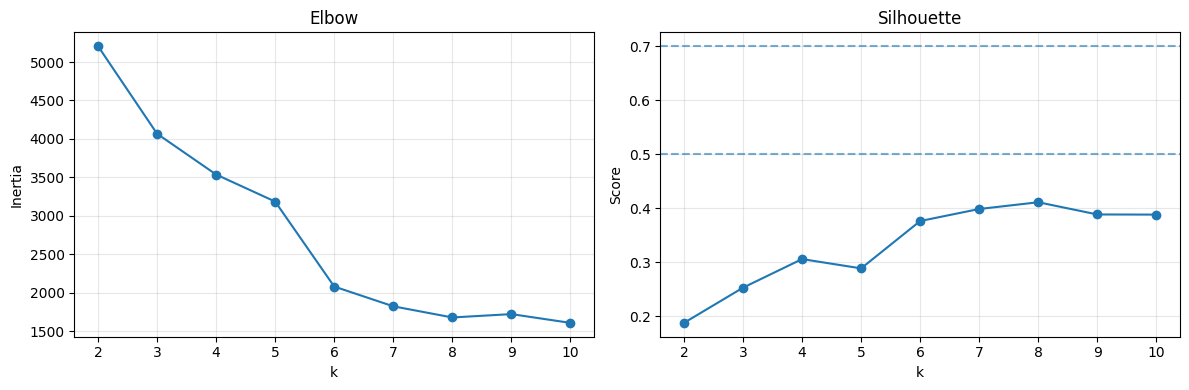

🎯 AUTO-SELECTED k = 7  (raw silhouette = 0.398, min cluster share = 5.1%, penalized score = 0.378)


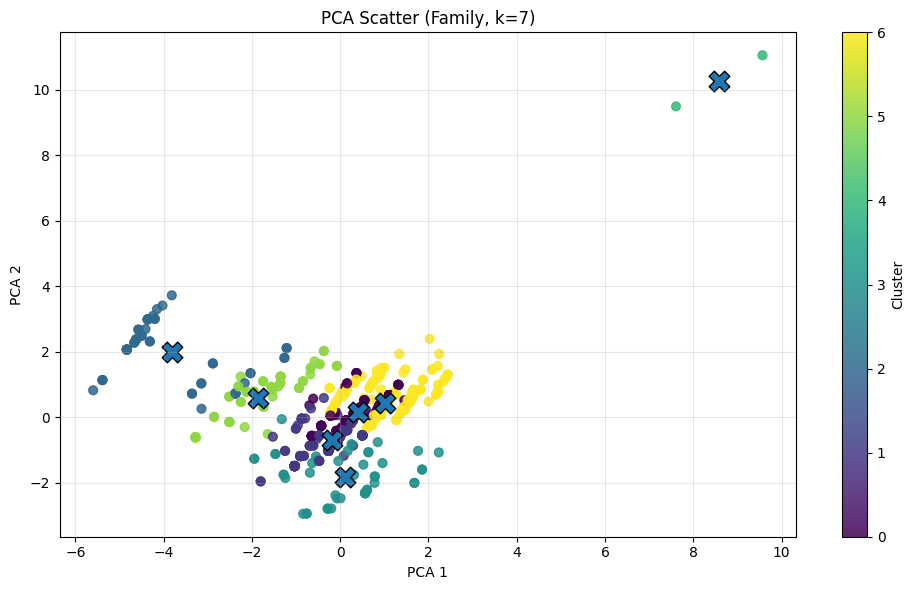

📊 FAMILY — CLUSTER PROFILING

👥 CLUSTER SIZES:
  Cluster 0: 271 (27.0%)
  Cluster 1: 318 (31.7%)
  Cluster 2: 54 (5.4%)
  Cluster 3: 51 (5.1%)
  Cluster 4: 2 (0.2%)
  Cluster 5: 62 (6.2%)
  Cluster 6: 244 (24.4%)

🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):
                                                                                       Feature       Score       p_value metric
                                                                           Marital Status: [C] 3595.009585  0.000000e+00      F
                                                                 Number of Family Members: [G]  393.975809 8.464579e-259      F
                                                  Do the children live with their parents? [I]  381.719805 5.037666e-254      F
Has there been a change in the Number of Family Members: in the past 5 years? If yes, how? [L]  367.332188 2.787492e-248      F
                                                                       Number of Children: [H]  173.0030

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


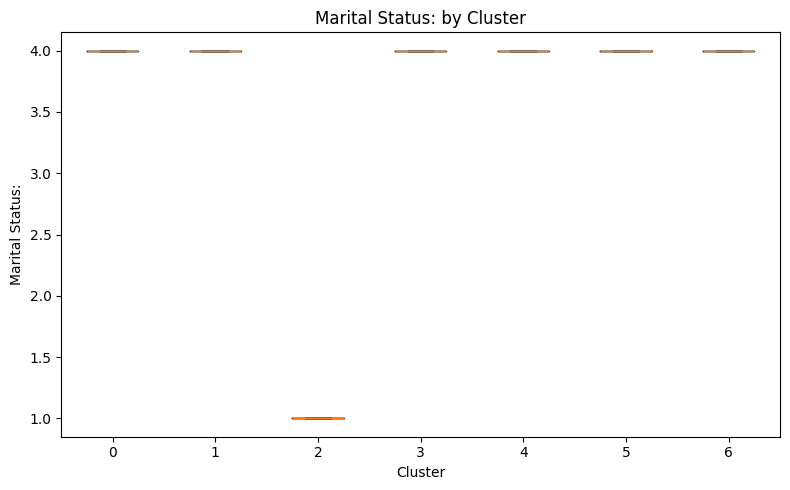

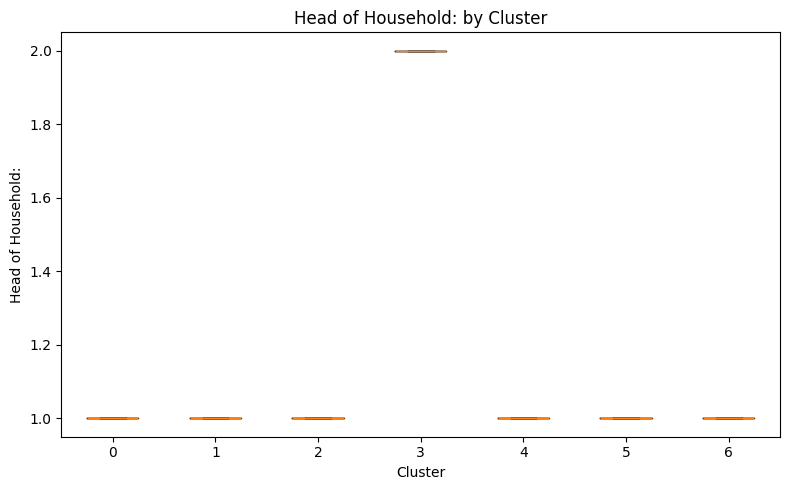

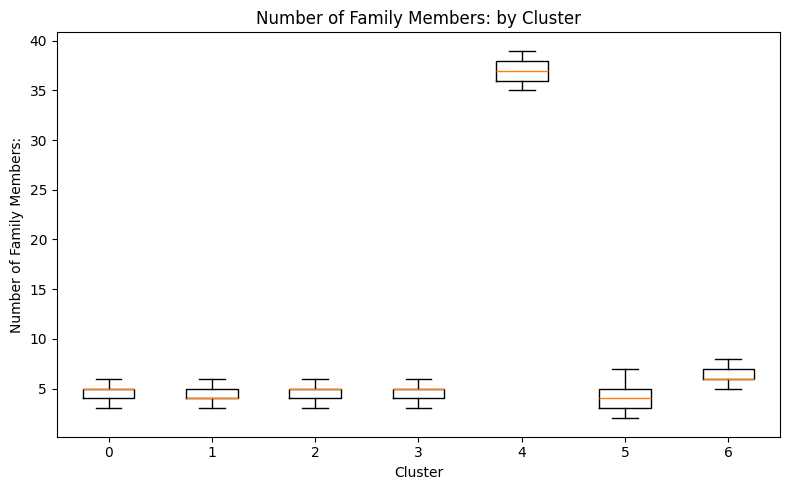

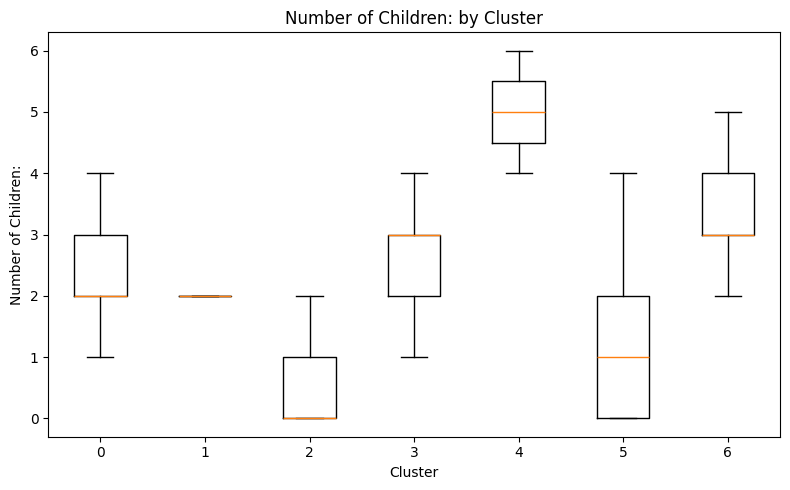

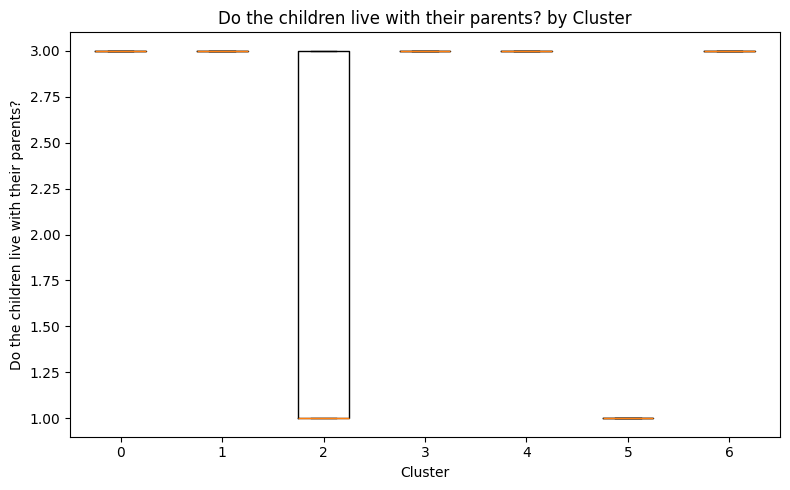

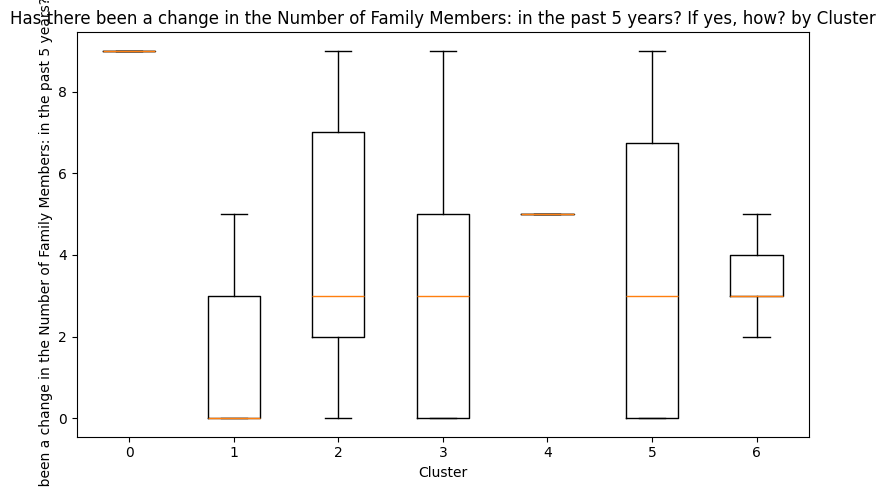

💡 FAMILY — BUSINESS INSIGHTS

📋 CLUSTER 0:
   no strong option-level deviations

📋 CLUSTER 1:
   no strong option-level deviations

📋 CLUSTER 2:
   no strong option-level deviations

📋 CLUSTER 3:
   no strong option-level deviations

📋 CLUSTER 4:
   no strong option-level deviations

📋 CLUSTER 5:
   no strong option-level deviations

📋 CLUSTER 6:
   no strong option-level deviations

📊 Average silhouette score: 0.406

Saved files:
 - clustered_output_Family.csv
 - anova_top_features_Family.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for both output files.


In [ ]:
# ============================================================
# Universal Category-wise Clustering & Profiling
# (Interactive upload, English labels, multi-answer aware)
# ============================================================

import os, io, re, math, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Tuple, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import f_classif, chi2

# -----------------------------
# CONFIG (edit if you like)
# -----------------------------
RANDOM_STATE = 42
K_RANGE = range(2, 11)
HIGH_MISSING_THRESH = 0.60

# k-selection guardrails (to avoid tiny, hard-to-interpret clusters)
MIN_CLUSTER_FRAC = 0.03   # reject k if any cluster <3% of samples
PREFER_K_MAX     = 6      # gently penalize k above this for interpretability

# Insights tuning
N_TOP_UP   = 3     # how many higher options to list per base
N_TOP_DOWN = 3     # how many lower options to list per base
EFFECT_PP  = 5.0   # only show lifts with |Δ| >= 5 percentage points

DEFAULT_CATEGORY_NAME = "Category"

# Bases you often want to protect from high-missing drop & narrate against (optional)
DEFAULT_PRIORITY_BASES = ["BR","BK","CE","CH","AB","Y","T"]


# ============================================================
# 0) INTERACTIVE UPLOADS (Colab OR Jupyter)
# ============================================================
def upload_two_excel_files():
    """Return (enc_bytes, key_bytes, enc_name, key_name) from an upload widget."""
    # Try Google Colab
    try:
        from google.colab import files  # type: ignore
        print("Please upload TWO files: (1) Encoded dataset, (2) Key sheet.")
        up = files.upload()
        if len(up) != 2:
            raise ValueError("Please upload exactly two files.")
        names = list(up.keys())
        enc_name, key_name = None, None
        enc_bytes, key_bytes = None, None
        for n in names:
            if "key" in n.lower() or "sheet" in n.lower():
                key_name, key_bytes = n, up[n]
            else:
                enc_name, enc_bytes = n, up[n]
        if not enc_bytes or not key_bytes:
            enc_name, enc_bytes = names[0], up[names[0]]
            key_name, key_bytes = names[1], up[names[1]]
        return io.BytesIO(enc_bytes), io.BytesIO(key_bytes), enc_name, key_name
    except Exception:
        pass

    # Jupyter widgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        up1 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload ENCODED .xlsx")
        up2 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload KEYSHEET .xlsx")
        btn = widgets.Button(description="Continue", button_style="primary")
        out = widgets.Output()
        display(up1, up2, btn, out)
        state = {"done": False, "enc": None, "key": None}
        def _on_click(b):
            with out:
                clear_output()
                if len(up1.value) != 1 or len(up2.value) != 1:
                    print("Please upload exactly one encoded file and one key sheet.")
                    return
                enc_item = list(up1.value.values())[0]
                key_item = list(up2.value.values())[0]
                state["enc"] = (io.BytesIO(enc_item["content"]), enc_item["metadata"]["name"])
                state["key"] = (io.BytesIO(key_item["content"]), key_item["metadata"]["name"])
                state["done"] = True
                print("Files captured. Proceeding…")
        btn.on_click(_on_click)
        while not state["done"]:
            time.sleep(0.2)
        (enc_bytes, enc_name) = state["enc"]
        (key_bytes, key_name) = state["key"]
        return enc_bytes, key_bytes, enc_name, key_name
    except Exception as e:
        raise RuntimeError("Upload widget not available. Please run in Colab/Jupyter.") from e


# ============================================================
# 1) MAPPING & MULTI-ANSWER LOGIC
# ============================================================
RAW_CODE_PAT      = re.compile(r"^([A-Z]+)(\d*)$")     # from raw headers: P, P1, P2…
RENAMED_CODE_PAT  = re.compile(r"\[([A-Z]+)(\d*)\]$")  # from renamed headers: … [P1]

def detect_bases_from_raw(df_raw: pd.DataFrame) -> Dict[str, List[str]]:
    bases = defaultdict(list)
    for c in df_raw.columns.astype(str):
        m = RAW_CODE_PAT.match(c)
        if m:
            bases[m.group(1)].append(c)
    return bases

def build_mapping(df_encoded: pd.DataFrame, key_df: pd.DataFrame) -> Dict[str, str]:
    encoded_cols = set(df_encoded.columns.astype(str))
    best_col, best_overlap = None, -1
    for col in key_df.columns:
        vals = key_df[col].astype(str).str.strip()
        # allow letters+digits in key sheet codes
        overlap = len(set(vals[vals.str.fullmatch(r"[A-Z]{1,3}\d*", na=False)]).intersection(encoded_cols))
        if overlap > best_overlap:
            best_col, best_overlap = col, overlap
    name_col = max([c for c in key_df.columns if c != best_col] or [key_df.columns[0]],
                   key=lambda c: key_df[c].astype(str).str.len().mean())
    mapping = {}
    for code, name in zip(
        key_df[best_col].astype(str).str.strip(),
        key_df[name_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ):
        if code in encoded_cols and name:
            mapping[code] = name
    return mapping

def rename_with_english_and_code(df_raw: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    new_cols = [f"{mapping.get(c,c)} [{c}]" for c in df_raw.columns.astype(str)]
    out = df_raw.copy()
    out.columns = new_cols
    return out

def group_by_base_after_rename(df_named: pd.DataFrame) -> Dict[str, List[str]]:
    by_base = defaultdict(list)
    for col in df_named.columns:
        m = RENAMED_CODE_PAT.search(col)
        if m:
            by_base[m.group(1)].append(col)
    return by_base

def english_stem_for_base(base: str, cols: List[str]) -> str:
    english_parts = [re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip() for c in cols]
    firsts = [p.split(":")[0].split("—")[0].strip() for p in english_parts]
    if len(set(firsts)) == 1:
        return firsts[0]
    return max(set(english_parts), key=english_parts.count) if english_parts else base

def prop(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(np.nanmean(s)) if s.size else np.nan


# ============================================================
# 2) FEATURE PREPARATION (numeric only; keep per-option binaries)
# ============================================================
def maybe_reduce_single_select(num_df: pd.DataFrame, by_base: Dict[str, List[str]],
                               threshold: float = 0.95) -> pd.DataFrame:
    """
    If a 'multi-answer' base is actually single-select (row sum == 1 in >= threshold of rows),
    drop the least prevalent option as a reference to reduce collinearity.
    """
    for b, cols in by_base.items():
        cols = [c for c in cols if c in num_df.columns]
        if len(cols) < 2:
            continue
        sums = num_df[cols].fillna(0).sum(axis=1)
        if (sums == 1).mean() >= threshold:
            prevalences = num_df[cols].mean().sort_values()
            drop_col = prevalences.index[0]
            num_df.drop(columns=[drop_col], inplace=True, errors="ignore")
    return num_df

def prepare_numeric(df_named: pd.DataFrame,
                    by_base: Dict[str, List[str]],
                    priority_bases: Optional[List[str]] = None,
                    high_missing_thresh: float = HIGH_MISSING_THRESH):
    num_df = df_named.select_dtypes(include=[np.number]).copy()
    num_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    all_nan_cols = num_df.columns[num_df.isna().all()].tolist()
    num_df.drop(columns=all_nan_cols, inplace=True, errors="ignore")

    priority_cols = set()
    if priority_bases:
        for b in priority_bases:
            for col in by_base.get(b, []):
                if col in num_df.columns:
                    priority_cols.add(col)

    miss = num_df.isna().mean()
    high_missing_cols = [c for c, m in miss.items() if (m > high_missing_thresh) and (c not in priority_cols)]
    num_df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

    # Optional: de-collinearize disguised single-selects
    num_df = maybe_reduce_single_select(num_df, by_base, threshold=0.95)

    # Drop constants (pre-impute)
    nunique = num_df.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    num_df.drop(columns=const_cols, inplace=True, errors="ignore")

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(num_df)

    # Drop constants AFTER impute (sometimes impute makes a column constant)
    _tmp = pd.DataFrame(X_imputed, columns=num_df.columns)
    const_after = _tmp.nunique(dropna=True)
    const_after_cols = const_after[const_after <= 1].index.tolist()
    if const_after_cols:
        num_df.drop(columns=const_after_cols, inplace=True, errors="ignore")
        X_imputed = SimpleImputer(strategy="median").fit_transform(num_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("=== FEATURE PREPARATION ===")
    print(f"Remaining numeric features: {num_df.shape[1]}")
    print(f"- Dropped all-NaN: {len(all_nan_cols)} | High-missing: {len(high_missing_cols)} "
          f"| Constants pre: {len(const_cols)} | post: {len(const_after_cols)}")

    return num_df, X_imputed, X_scaled


# ============================================================
# 3) k SELECTION with guardrails + FINAL CLUSTERING
# ============================================================
def choose_k_with_guards(X_scaled, k_range=K_RANGE, random_state=RANDOM_STATE,
                         min_cluster_frac=MIN_CLUSTER_FRAC, prefer_k_max=PREFER_K_MAX):
    inertia_list, sil_list, label_sets = [], [], []

    for k in k_range:
        mb = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init=5,
                             batch_size=256, max_iter=100, reassignment_ratio=0.01)
        labels_k = mb.fit_predict(X_scaled)
        label_sets.append(labels_k)
        inertia_list.append(mb.inertia_)
        sil_list.append(silhouette_score(X_scaled, labels_k))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(list(k_range), inertia_list, marker='o'); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.grid(True, alpha=0.3)
    ax2.plot(list(k_range), sil_list, marker='o'); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.5, linestyle='--', alpha=0.6); ax2.axhline(y=0.7, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # Penalize k with tiny clusters or too large k
    n = X_scaled.shape[0]
    candidates = []
    for k, sil, labels in zip(k_range, sil_list, label_sets):
        counts = np.bincount(labels)
        smallest_frac = counts.min() / n
        penalty = 0.0
        if k > prefer_k_max:       penalty += 0.02 * (k - prefer_k_max)   # gentle k penalty
        if smallest_frac < min_cluster_frac: penalty += 0.20              # strong tiny-cluster penalty
        candidates.append((k, sil - penalty, sil, smallest_frac))
    best_k, penalized, raw_sil, min_frac = max(candidates, key=lambda t: t[1])
    print(f"🎯 AUTO-SELECTED k = {best_k}  (raw silhouette = {raw_sil:.3f}, "
          f"min cluster share = {min_frac*100:.1f}%, penalized score = {penalized:.3f})")
    return best_k, inertia_list, sil_list

def run_kmeans(X_scaled, best_k, random_state=RANDOM_STATE):
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_scaled)
    return km, labels


# ============================================================
# 4) PCA + PROFILING (ANOVA/χ²) + INSIGHTS
# ============================================================
def plot_pca(X_scaled, labels, kmeans, category):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40, alpha=0.85)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=220, edgecolor='k')
    plt.title(f"PCA Scatter ({category}, k={kmeans.n_clusters})")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.colorbar(sc, label="Cluster"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return pca, X_pca, centroids_pca

def rank_features_discriminative(X_imp_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    # Try ANOVA F first
    try:
        F, p = f_classif(X_imp_df, labels)
        df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": F, "p_value": p, "metric": "F"})
        return df.replace([np.inf, -np.inf], np.nan)
    except Exception:
        pass
    # Fallback to chi-square (requires non-negative)
    X_nonneg = (X_imp_df - X_imp_df.min()).clip(lower=0.0)
    chi, p = chi2(X_nonneg, labels)
    df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": chi, "p_value": p, "metric": "chi2"})
    return df.replace([np.inf, -np.inf], np.nan)

def profile_clusters(category, df_named, num_df, X_imputed, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    print("="*60); print(f"📊 {category.upper()} — CLUSTER PROFILING"); print("="*60)
    sizes = df["Cluster"].value_counts().sort_index()
    total = len(df)
    print("\n👥 CLUSTER SIZES:")
    for cid, sz in sizes.items():
        print(f"  Cluster {cid}: {sz} ({sz/total*100:.1f}%)")

    X_imp_df = pd.DataFrame(X_imputed, columns=num_df.columns, index=df.index)
    ranked = rank_features_discriminative(X_imp_df, df["Cluster"])
    anova = (ranked.dropna(subset=["Score","p_value"])
                   .sort_values("Score", ascending=False)
                   .reset_index(drop=True))
    print("\n🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):")
    print(anova.head(12).to_string(index=False))

    # Boxplots (up to 6 features)
    feats = list(num_df.columns)[:6]
    for feat in feats:
        data_by_cluster = [df.loc[df["Cluster"]==c, feat].dropna().values for c in sorted(df["Cluster"].unique())]
        plt.figure(figsize=(8,5))
        plt.boxplot(data_by_cluster, tick_labels=[str(c) for c in sorted(df["Cluster"].unique())], showfliers=False)
        label = re.sub(r"\s*\[[^\]]+\]\s*$","", feat)
        plt.title(f"{label} by Cluster"); plt.xlabel("Cluster"); plt.ylabel(label)
        plt.tight_layout(); plt.show()

    return sizes, anova

def business_insights(category, df_named, num_df, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    by_base = group_by_base_after_rename(df_named)
    base_stem = {b: english_stem_for_base(b, cols) for b, cols in by_base.items()}
    overall = df.mean(numeric_only=True)

    print("="*60); print(f"💡 {category.upper()} — BUSINESS INSIGHTS"); print("="*60)

    def clean_label(col: str) -> str:
        return re.sub(r"\s*\[[^\]]+\]\s*$", "", col).strip()

    for cid in sorted(df["Cluster"].unique()):
        seg = df[df["Cluster"]==cid]
        print(f"\n📋 CLUSTER {cid}:")
        notes = []
        for b, cols in by_base.items():
            cols = [c for c in cols if c in num_df.columns]
            if len(cols) <= 1:
                continue

            # Option-level lifts with effect-size threshold
            lifts = []
            for col in cols:
                seg_p = prop(seg[col]); all_p = prop(df[col])
                if np.isnan(seg_p) or np.isnan(all_p):
                    continue
                diff_pp = (seg_p - all_p) * 100
                if abs(diff_pp) >= EFFECT_PP:
                    lifts.append((col, diff_pp, seg_p, all_p))
            if not lifts:
                continue

            lifts_sorted = sorted(lifts, key=lambda x: x[1], reverse=True)
            up   = [f"{clean_label(c)} (+{dpp:.0f} pp)" for c,dpp,_,_ in lifts_sorted if dpp > 0][:N_TOP_UP]
            down = [f"{clean_label(c)} ({dpp:.0f} pp)"  for c,dpp,_,_ in reversed(lifts_sorted) if dpp < 0][:N_TOP_DOWN]

            # “Any — stem” only if informative
            any_name = f"Any — {base_stem[b]} [{b}_ANY]"
            df[any_name] = (df[cols].fillna(0) > 0).any(axis=1).astype(int)
            seg_any = df.loc[df["Cluster"]==cid, any_name].mean()*100
            all_any = df[any_name].mean()*100
            any_txt = f"; Any: {seg_any:.0f}% vs {all_any:.0f}%" if (1.0 < all_any < 99.0) else ""

            if up or down:
                parts = []
                if up: parts.append(", ".join(up))
                if down: parts.append(", ".join(down))
                notes.append(f"{base_stem[b]} ↑/↓: {'; '.join(parts)}{any_txt}")

        print("   " + ("; ".join(notes) if notes else "no strong option-level deviations"))


# ============================================================
# 5) MAIN RUNNER (ONE CATEGORY)
# ============================================================
def run_category_pipeline(category_name: str,
                          enc_bytes: io.BytesIO,
                          key_bytes: io.BytesIO,
                          priority_bases: Optional[List[str]] = None):
    # Load
    df_raw = pd.read_excel(enc_bytes, sheet_name=0)
    key_df = pd.read_excel(key_bytes, sheet_name=0)

    # Detect bases from raw (P1,P2,… → base P). Optionally use as priority bases.
    raw_bases = detect_bases_from_raw(df_raw)
    if priority_bases is None:
        # protect EVERYTHING present in this category + some global defaults
        priority_bases = sorted(set(raw_bases.keys()).union(DEFAULT_PRIORITY_BASES))

    # Map & rename to English [CODE]
    mapping = build_mapping(df_raw, key_df)
    df_named = rename_with_english_and_code(df_raw, mapping)

    # Group by base after rename
    by_base = group_by_base_after_rename(df_named)

    # Feature prep
    num_df, X_imputed, X_scaled = prepare_numeric(
        df_named, by_base, priority_bases=priority_bases, high_missing_thresh=HIGH_MISSING_THRESH
    )
    if num_df.shape[1] == 0:
        print("❌ No numeric features left after cleaning.")
        return df_named

    # k-selection (guarded) + final KMeans
    best_k, _, _ = choose_k_with_guards(X_scaled, k_range=K_RANGE)
    kmeans, labels = run_kmeans(X_scaled, best_k)

    # PCA
    plot_pca(X_scaled, labels, kmeans, category_name)

    # Profiling + insights
    sizes, anova = profile_clusters(category_name, df_named, num_df, X_imputed, labels)
    business_insights(category_name, df_named, num_df, labels)

    # Silhouette per-sample
    try:
        sil = silhouette_samples(X_scaled, labels)
        avg_sil = sil.mean()
    except Exception as e:
        sil = np.full(shape=(len(df_named),), fill_value=np.nan)
        avg_sil = np.nan
        print("⚠️  Could not compute silhouette per-sample:", e)

    # Output DF
    df_out = df_named.copy()
    df_out["Cluster"] = labels
    df_out["Silhouette_Score"] = sil
    print(f"\n📊 Average silhouette score: {avg_sil:.3f}")

    # Save
    safe_cat = re.sub(r"[^A-Za-z0-9_-]+", "_", category_name.strip() or "Category")
    out_csv = f"clustered_output_{safe_cat}.csv"
    anova_csv = f"anova_top_features_{safe_cat}.csv"
    df_out.to_csv(out_csv, index=False)
    anova.to_csv(anova_csv, index=False)
    print("\nSaved files:")
    print(" -", out_csv)
    print(" -", anova_csv)

    # -----------------------------
    # AUTO-DOWNLOAD (Colab only)
    # -----------------------------
    try:
        from google.colab import files  # type: ignore
        files.download(out_csv)
        files.download(anova_csv)
        print("⬇️ Download started for both output files.")
    except Exception:
        pass

    return df_out


# ============================================================
# 6) GO: Ask, Upload, Run
# ============================================================
category_name = input(f"Enter category name (default '{DEFAULT_CATEGORY_NAME}'): ").strip() or DEFAULT_CATEGORY_NAME
enc_bytes, key_bytes, enc_name, key_name = upload_two_excel_files()
print(f"\n✅ Encoded: {enc_name}\n✅ Keysheet: {key_name}\nCategory: {category_name}")

df_with_clusters = run_category_pipeline(
    category_name=category_name,
    enc_bytes=enc_bytes,
    key_bytes=key_bytes,
    # priority_bases=None  # leave as None to auto-protect all bases + defaults
)


Enter category name (default 'Category'): Financial Behavior
Please upload TWO files: (1) Encoded dataset, (2) Key sheet.


Saving Financial_behavior_encoded_dataset.xlsx to Financial_behavior_encoded_dataset.xlsx
Saving Financial_behavior_key_sheet.xlsx to Financial_behavior_key_sheet.xlsx

✅ Encoded: Financial_behavior_encoded_dataset.xlsx
✅ Keysheet: Financial_behavior_key_sheet.xlsx
Category: Financial Behavior
=== FEATURE PREPARATION ===
Remaining numeric features: 40
- Dropped all-NaN: 0 | High-missing: 0 | Constants pre: 0 | post: 0


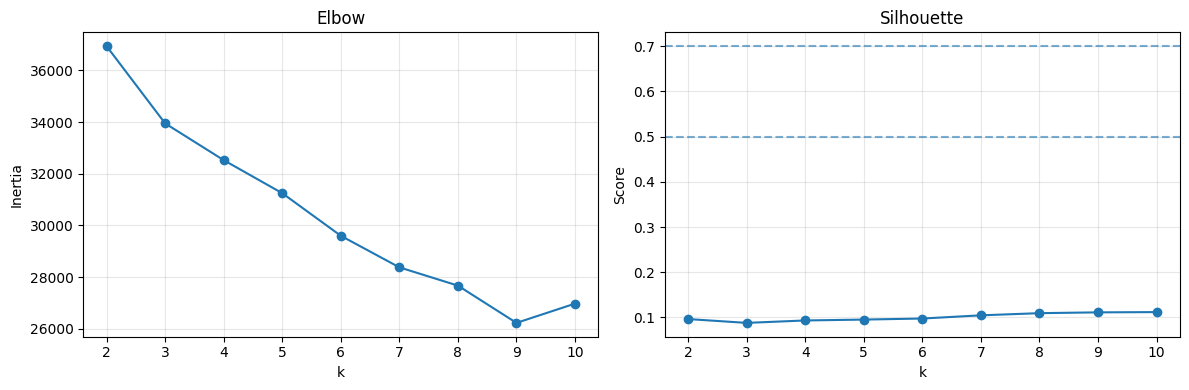

🎯 AUTO-SELECTED k = 6  (raw silhouette = 0.098, min cluster share = 6.8%, penalized score = 0.098)


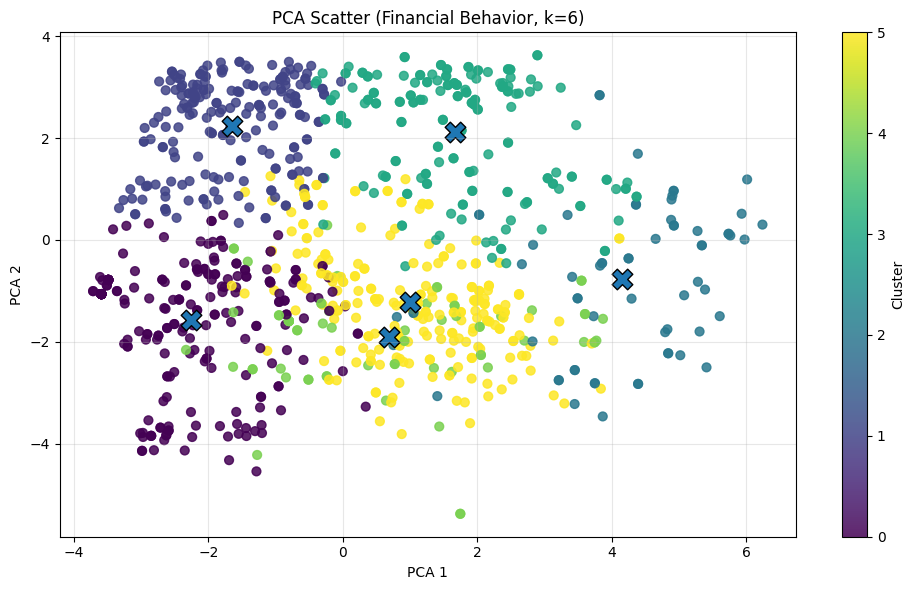

📊 FINANCIAL BEHAVIOR — CLUSTER PROFILING

👥 CLUSTER SIZES:
  Cluster 0: 237 (23.7%)
  Cluster 1: 203 (20.3%)
  Cluster 2: 65 (6.5%)
  Cluster 3: 186 (18.6%)
  Cluster 4: 69 (6.9%)
  Cluster 5: 242 (24.2%)

🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):
                                                                                                                   Feature       Score       p_value metric
Have you ever participated in any financial management or savings training provided by a microfinance institution? [AU_03] 6579.906454  0.000000e+00      F
Have you ever participated in any financial management or savings training provided by a microfinance institution? [AU_02] 6579.906454  0.000000e+00      F
                                                                                                             AV_06 [AV_06] 4200.887389  0.000000e+00      F
                                                                                                             AV_04 [AV_04] 4200.

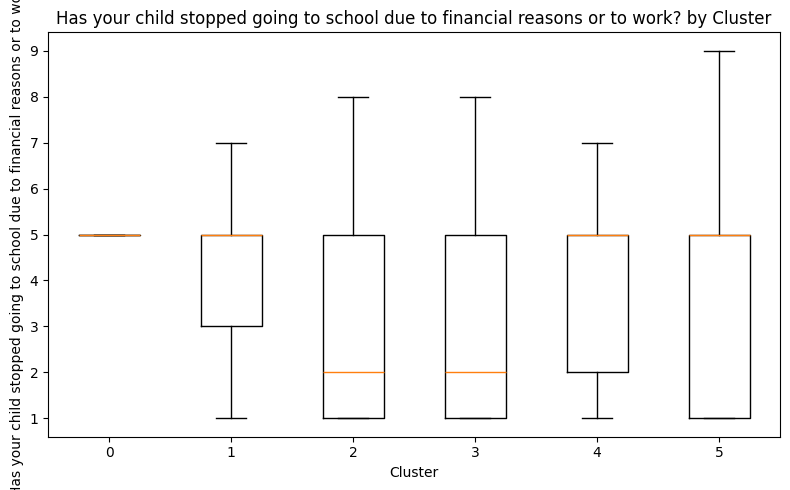

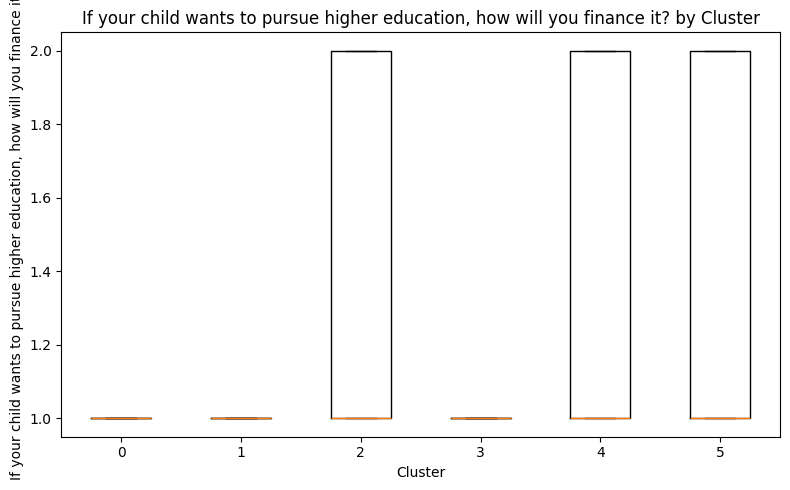

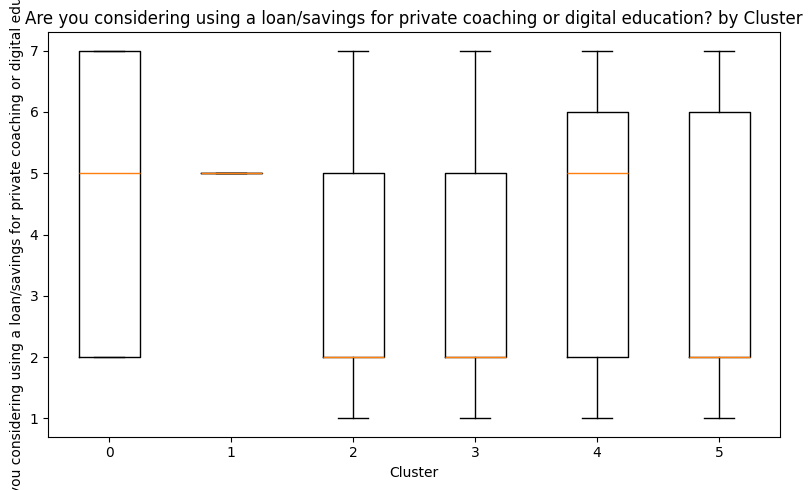

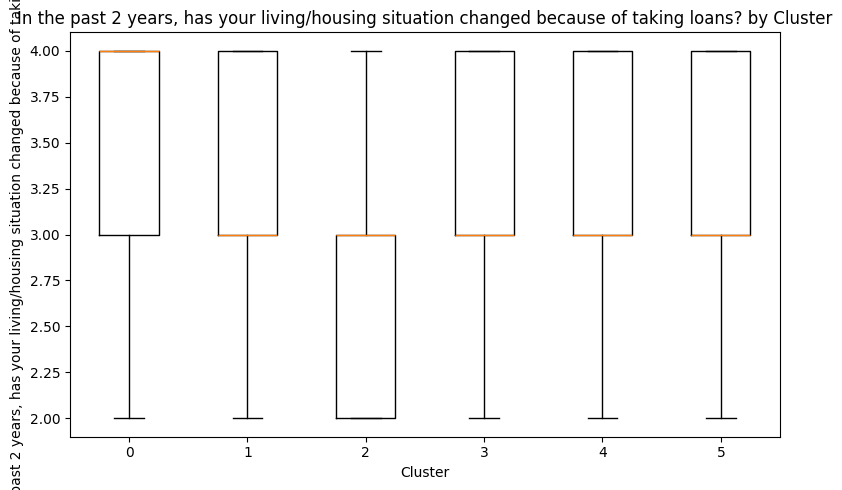

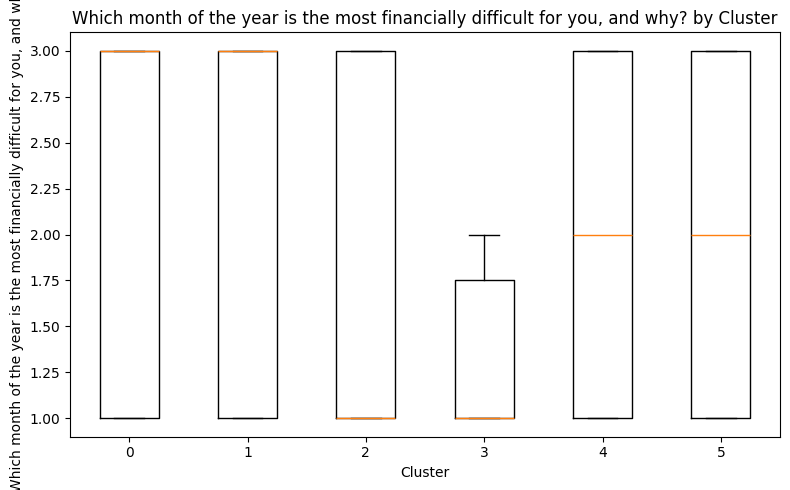

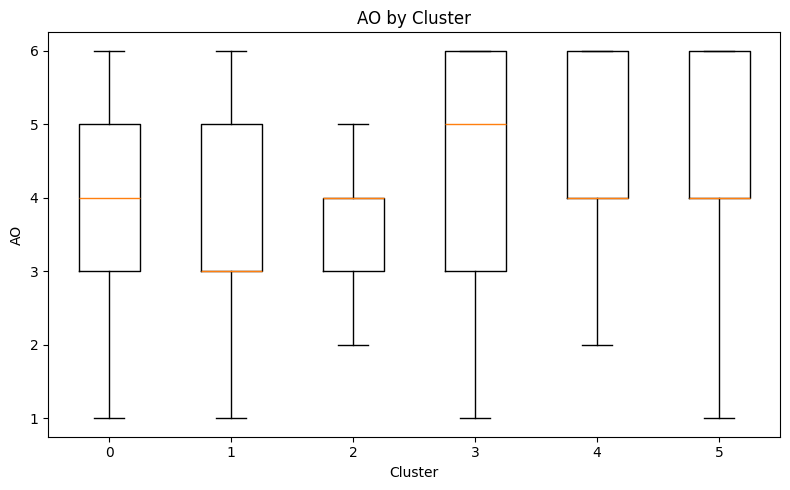

💡 FINANCIAL BEHAVIOR — BUSINESS INSIGHTS

📋 CLUSTER 0:
   no strong option-level deviations

📋 CLUSTER 1:
   no strong option-level deviations

📋 CLUSTER 2:
   no strong option-level deviations

📋 CLUSTER 3:
   no strong option-level deviations

📋 CLUSTER 4:
   no strong option-level deviations

📋 CLUSTER 5:
   no strong option-level deviations

📊 Average silhouette score: 0.106

Saved files:
 - clustered_output_Financial_Behavior.csv
 - anova_top_features_Financial_Behavior.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for both output files.


In [ ]:
# ============================================================
# Universal Category-wise Clustering & Profiling
# (Interactive upload, English labels, multi-answer aware)
# ============================================================

import os, io, re, math, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Tuple, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import f_classif, chi2

# -----------------------------
# CONFIG (edit if you like)
# -----------------------------
RANDOM_STATE = 42
K_RANGE = range(2, 11)
HIGH_MISSING_THRESH = 0.60

# k-selection guardrails (to avoid tiny, hard-to-interpret clusters)
MIN_CLUSTER_FRAC = 0.03   # reject k if any cluster <3% of samples
PREFER_K_MAX     = 6      # gently penalize k above this for interpretability

# Insights tuning
N_TOP_UP   = 3     # how many higher options to list per base
N_TOP_DOWN = 3     # how many lower options to list per base
EFFECT_PP  = 5.0   # only show lifts with |Δ| >= 5 percentage points

DEFAULT_CATEGORY_NAME = "Category"

# Bases you often want to protect from high-missing drop & narrate against (optional)
DEFAULT_PRIORITY_BASES = ["BR","BK","CE","CH","AB","Y","T"]


# ============================================================
# 0) INTERACTIVE UPLOADS (Colab OR Jupyter)
# ============================================================
def upload_two_excel_files():
    """Return (enc_bytes, key_bytes, enc_name, key_name) from an upload widget."""
    # Try Google Colab
    try:
        from google.colab import files  # type: ignore
        print("Please upload TWO files: (1) Encoded dataset, (2) Key sheet.")
        up = files.upload()
        if len(up) != 2:
            raise ValueError("Please upload exactly two files.")
        names = list(up.keys())
        enc_name, key_name = None, None
        enc_bytes, key_bytes = None, None
        for n in names:
            if "key" in n.lower() or "sheet" in n.lower():
                key_name, key_bytes = n, up[n]
            else:
                enc_name, enc_bytes = n, up[n]
        if not enc_bytes or not key_bytes:
            enc_name, enc_bytes = names[0], up[names[0]]
            key_name, key_bytes = names[1], up[names[1]]
        return io.BytesIO(enc_bytes), io.BytesIO(key_bytes), enc_name, key_name
    except Exception:
        pass

    # Jupyter widgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        up1 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload ENCODED .xlsx")
        up2 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload KEYSHEET .xlsx")
        btn = widgets.Button(description="Continue", button_style="primary")
        out = widgets.Output()
        display(up1, up2, btn, out)
        state = {"done": False, "enc": None, "key": None}
        def _on_click(b):
            with out:
                clear_output()
                if len(up1.value) != 1 or len(up2.value) != 1:
                    print("Please upload exactly one encoded file and one key sheet.")
                    return
                enc_item = list(up1.value.values())[0]
                key_item = list(up2.value.values())[0]
                state["enc"] = (io.BytesIO(enc_item["content"]), enc_item["metadata"]["name"])
                state["key"] = (io.BytesIO(key_item["content"]), key_item["metadata"]["name"])
                state["done"] = True
                print("Files captured. Proceeding…")
        btn.on_click(_on_click)
        while not state["done"]:
            time.sleep(0.2)
        (enc_bytes, enc_name) = state["enc"]
        (key_bytes, key_name) = state["key"]
        return enc_bytes, key_bytes, enc_name, key_name
    except Exception as e:
        raise RuntimeError("Upload widget not available. Please run in Colab/Jupyter.") from e


# ============================================================
# 1) MAPPING & MULTI-ANSWER LOGIC
# ============================================================
RAW_CODE_PAT      = re.compile(r"^([A-Z]+)(\d*)$")     # from raw headers: P, P1, P2…
RENAMED_CODE_PAT  = re.compile(r"\[([A-Z]+)(\d*)\]$")  # from renamed headers: … [P1]

def detect_bases_from_raw(df_raw: pd.DataFrame) -> Dict[str, List[str]]:
    bases = defaultdict(list)
    for c in df_raw.columns.astype(str):
        m = RAW_CODE_PAT.match(c)
        if m:
            bases[m.group(1)].append(c)
    return bases

def build_mapping(df_encoded: pd.DataFrame, key_df: pd.DataFrame) -> Dict[str, str]:
    encoded_cols = set(df_encoded.columns.astype(str))
    best_col, best_overlap = None, -1
    for col in key_df.columns:
        vals = key_df[col].astype(str).str.strip()
        # allow letters+digits in key sheet codes
        overlap = len(set(vals[vals.str.fullmatch(r"[A-Z]{1,3}\d*", na=False)]).intersection(encoded_cols))
        if overlap > best_overlap:
            best_col, best_overlap = col, overlap
    name_col = max([c for c in key_df.columns if c != best_col] or [key_df.columns[0]],
                   key=lambda c: key_df[c].astype(str).str.len().mean())
    mapping = {}
    for code, name in zip(
        key_df[best_col].astype(str).str.strip(),
        key_df[name_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ):
        if code in encoded_cols and name:
            mapping[code] = name
    return mapping

def rename_with_english_and_code(df_raw: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    new_cols = [f"{mapping.get(c,c)} [{c}]" for c in df_raw.columns.astype(str)]
    out = df_raw.copy()
    out.columns = new_cols
    return out

def group_by_base_after_rename(df_named: pd.DataFrame) -> Dict[str, List[str]]:
    by_base = defaultdict(list)
    for col in df_named.columns:
        m = RENAMED_CODE_PAT.search(col)
        if m:
            by_base[m.group(1)].append(col)
    return by_base

def english_stem_for_base(base: str, cols: List[str]) -> str:
    english_parts = [re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip() for c in cols]
    firsts = [p.split(":")[0].split("—")[0].strip() for p in english_parts]
    if len(set(firsts)) == 1:
        return firsts[0]
    return max(set(english_parts), key=english_parts.count) if english_parts else base

def prop(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(np.nanmean(s)) if s.size else np.nan


# ============================================================
# 2) FEATURE PREPARATION (numeric only; keep per-option binaries)
# ============================================================
def maybe_reduce_single_select(num_df: pd.DataFrame, by_base: Dict[str, List[str]],
                               threshold: float = 0.95) -> pd.DataFrame:
    """
    If a 'multi-answer' base is actually single-select (row sum == 1 in >= threshold of rows),
    drop the least prevalent option as a reference to reduce collinearity.
    """
    for b, cols in by_base.items():
        cols = [c for c in cols if c in num_df.columns]
        if len(cols) < 2:
            continue
        sums = num_df[cols].fillna(0).sum(axis=1)
        if (sums == 1).mean() >= threshold:
            prevalences = num_df[cols].mean().sort_values()
            drop_col = prevalences.index[0]
            num_df.drop(columns=[drop_col], inplace=True, errors="ignore")
    return num_df

def prepare_numeric(df_named: pd.DataFrame,
                    by_base: Dict[str, List[str]],
                    priority_bases: Optional[List[str]] = None,
                    high_missing_thresh: float = HIGH_MISSING_THRESH):
    num_df = df_named.select_dtypes(include=[np.number]).copy()
    num_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    all_nan_cols = num_df.columns[num_df.isna().all()].tolist()
    num_df.drop(columns=all_nan_cols, inplace=True, errors="ignore")

    priority_cols = set()
    if priority_bases:
        for b in priority_bases:
            for col in by_base.get(b, []):
                if col in num_df.columns:
                    priority_cols.add(col)

    miss = num_df.isna().mean()
    high_missing_cols = [c for c, m in miss.items() if (m > high_missing_thresh) and (c not in priority_cols)]
    num_df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

    # Optional: de-collinearize disguised single-selects
    num_df = maybe_reduce_single_select(num_df, by_base, threshold=0.95)

    # Drop constants (pre-impute)
    nunique = num_df.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    num_df.drop(columns=const_cols, inplace=True, errors="ignore")

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(num_df)

    # Drop constants AFTER impute (sometimes impute makes a column constant)
    _tmp = pd.DataFrame(X_imputed, columns=num_df.columns)
    const_after = _tmp.nunique(dropna=True)
    const_after_cols = const_after[const_after <= 1].index.tolist()
    if const_after_cols:
        num_df.drop(columns=const_after_cols, inplace=True, errors="ignore")
        X_imputed = SimpleImputer(strategy="median").fit_transform(num_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("=== FEATURE PREPARATION ===")
    print(f"Remaining numeric features: {num_df.shape[1]}")
    print(f"- Dropped all-NaN: {len(all_nan_cols)} | High-missing: {len(high_missing_cols)} "
          f"| Constants pre: {len(const_cols)} | post: {len(const_after_cols)}")

    return num_df, X_imputed, X_scaled


# ============================================================
# 3) k SELECTION with guardrails + FINAL CLUSTERING
# ============================================================
def choose_k_with_guards(X_scaled, k_range=K_RANGE, random_state=RANDOM_STATE,
                         min_cluster_frac=MIN_CLUSTER_FRAC, prefer_k_max=PREFER_K_MAX):
    inertia_list, sil_list, label_sets = [], [], []

    for k in k_range:
        mb = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init=5,
                             batch_size=256, max_iter=100, reassignment_ratio=0.01)
        labels_k = mb.fit_predict(X_scaled)
        label_sets.append(labels_k)
        inertia_list.append(mb.inertia_)
        sil_list.append(silhouette_score(X_scaled, labels_k))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(list(k_range), inertia_list, marker='o'); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.grid(True, alpha=0.3)
    ax2.plot(list(k_range), sil_list, marker='o'); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.5, linestyle='--', alpha=0.6); ax2.axhline(y=0.7, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # Penalize k with tiny clusters or too large k
    n = X_scaled.shape[0]
    candidates = []
    for k, sil, labels in zip(k_range, sil_list, label_sets):
        counts = np.bincount(labels)
        smallest_frac = counts.min() / n
        penalty = 0.0
        if k > prefer_k_max:       penalty += 0.02 * (k - prefer_k_max)   # gentle k penalty
        if smallest_frac < min_cluster_frac: penalty += 0.20              # strong tiny-cluster penalty
        candidates.append((k, sil - penalty, sil, smallest_frac))
    best_k, penalized, raw_sil, min_frac = max(candidates, key=lambda t: t[1])
    print(f"🎯 AUTO-SELECTED k = {best_k}  (raw silhouette = {raw_sil:.3f}, "
          f"min cluster share = {min_frac*100:.1f}%, penalized score = {penalized:.3f})")
    return best_k, inertia_list, sil_list

def run_kmeans(X_scaled, best_k, random_state=RANDOM_STATE):
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_scaled)
    return km, labels


# ============================================================
# 4) PCA + PROFILING (ANOVA/χ²) + INSIGHTS
# ============================================================
def plot_pca(X_scaled, labels, kmeans, category):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40, alpha=0.85)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=220, edgecolor='k')
    plt.title(f"PCA Scatter ({category}, k={kmeans.n_clusters})")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.colorbar(sc, label="Cluster"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return pca, X_pca, centroids_pca

def rank_features_discriminative(X_imp_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    # Try ANOVA F first
    try:
        F, p = f_classif(X_imp_df, labels)
        df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": F, "p_value": p, "metric": "F"})
        return df.replace([np.inf, -np.inf], np.nan)
    except Exception:
        pass
    # Fallback to chi-square (requires non-negative)
    X_nonneg = (X_imp_df - X_imp_df.min()).clip(lower=0.0)
    chi, p = chi2(X_nonneg, labels)
    df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": chi, "p_value": p, "metric": "chi2"})
    return df.replace([np.inf, -np.inf], np.nan)

def profile_clusters(category, df_named, num_df, X_imputed, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    print("="*60); print(f"📊 {category.upper()} — CLUSTER PROFILING"); print("="*60)
    sizes = df["Cluster"].value_counts().sort_index()
    total = len(df)
    print("\n👥 CLUSTER SIZES:")
    for cid, sz in sizes.items():
        print(f"  Cluster {cid}: {sz} ({sz/total*100:.1f}%)")

    X_imp_df = pd.DataFrame(X_imputed, columns=num_df.columns, index=df.index)
    ranked = rank_features_discriminative(X_imp_df, df["Cluster"])
    anova = (ranked.dropna(subset=["Score","p_value"])
                   .sort_values("Score", ascending=False)
                   .reset_index(drop=True))
    print("\n🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):")
    print(anova.head(12).to_string(index=False))

    # Boxplots (up to 6 features)
    feats = list(num_df.columns)[:6]
    for feat in feats:
        data_by_cluster = [df.loc[df["Cluster"]==c, feat].dropna().values for c in sorted(df["Cluster"].unique())]
        plt.figure(figsize=(8,5))
        plt.boxplot(data_by_cluster, tick_labels=[str(c) for c in sorted(df["Cluster"].unique())], showfliers=False)
        label = re.sub(r"\s*\[[^\]]+\]\s*$","", feat)
        plt.title(f"{label} by Cluster"); plt.xlabel("Cluster"); plt.ylabel(label)
        plt.tight_layout(); plt.show()

    return sizes, anova

def business_insights(category, df_named, num_df, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    by_base = group_by_base_after_rename(df_named)
    base_stem = {b: english_stem_for_base(b, cols) for b, cols in by_base.items()}
    overall = df.mean(numeric_only=True)

    print("="*60); print(f"💡 {category.upper()} — BUSINESS INSIGHTS"); print("="*60)

    def clean_label(col: str) -> str:
        return re.sub(r"\s*\[[^\]]+\]\s*$", "", col).strip()

    for cid in sorted(df["Cluster"].unique()):
        seg = df[df["Cluster"]==cid]
        print(f"\n📋 CLUSTER {cid}:")
        notes = []
        for b, cols in by_base.items():
            cols = [c for c in cols if c in num_df.columns]
            if len(cols) <= 1:
                continue

            # Option-level lifts with effect-size threshold
            lifts = []
            for col in cols:
                seg_p = prop(seg[col]); all_p = prop(df[col])
                if np.isnan(seg_p) or np.isnan(all_p):
                    continue
                diff_pp = (seg_p - all_p) * 100
                if abs(diff_pp) >= EFFECT_PP:
                    lifts.append((col, diff_pp, seg_p, all_p))
            if not lifts:
                continue

            lifts_sorted = sorted(lifts, key=lambda x: x[1], reverse=True)
            up   = [f"{clean_label(c)} (+{dpp:.0f} pp)" for c,dpp,_,_ in lifts_sorted if dpp > 0][:N_TOP_UP]
            down = [f"{clean_label(c)} ({dpp:.0f} pp)"  for c,dpp,_,_ in reversed(lifts_sorted) if dpp < 0][:N_TOP_DOWN]

            # “Any — stem” only if informative
            any_name = f"Any — {base_stem[b]} [{b}_ANY]"
            df[any_name] = (df[cols].fillna(0) > 0).any(axis=1).astype(int)
            seg_any = df.loc[df["Cluster"]==cid, any_name].mean()*100
            all_any = df[any_name].mean()*100
            any_txt = f"; Any: {seg_any:.0f}% vs {all_any:.0f}%" if (1.0 < all_any < 99.0) else ""

            if up or down:
                parts = []
                if up: parts.append(", ".join(up))
                if down: parts.append(", ".join(down))
                notes.append(f"{base_stem[b]} ↑/↓: {'; '.join(parts)}{any_txt}")

        print("   " + ("; ".join(notes) if notes else "no strong option-level deviations"))


# ============================================================
# 5) MAIN RUNNER (ONE CATEGORY)
# ============================================================
def run_category_pipeline(category_name: str,
                          enc_bytes: io.BytesIO,
                          key_bytes: io.BytesIO,
                          priority_bases: Optional[List[str]] = None):
    # Load
    df_raw = pd.read_excel(enc_bytes, sheet_name=0)
    key_df = pd.read_excel(key_bytes, sheet_name=0)

    # Detect bases from raw (P1,P2,… → base P). Optionally use as priority bases.
    raw_bases = detect_bases_from_raw(df_raw)
    if priority_bases is None:
        # protect EVERYTHING present in this category + some global defaults
        priority_bases = sorted(set(raw_bases.keys()).union(DEFAULT_PRIORITY_BASES))

    # Map & rename to English [CODE]
    mapping = build_mapping(df_raw, key_df)
    df_named = rename_with_english_and_code(df_raw, mapping)

    # Group by base after rename
    by_base = group_by_base_after_rename(df_named)

    # Feature prep
    num_df, X_imputed, X_scaled = prepare_numeric(
        df_named, by_base, priority_bases=priority_bases, high_missing_thresh=HIGH_MISSING_THRESH
    )
    if num_df.shape[1] == 0:
        print("❌ No numeric features left after cleaning.")
        return df_named

    # k-selection (guarded) + final KMeans
    best_k, _, _ = choose_k_with_guards(X_scaled, k_range=K_RANGE)
    kmeans, labels = run_kmeans(X_scaled, best_k)

    # PCA
    plot_pca(X_scaled, labels, kmeans, category_name)

    # Profiling + insights
    sizes, anova = profile_clusters(category_name, df_named, num_df, X_imputed, labels)
    business_insights(category_name, df_named, num_df, labels)

    # Silhouette per-sample
    try:
        sil = silhouette_samples(X_scaled, labels)
        avg_sil = sil.mean()
    except Exception as e:
        sil = np.full(shape=(len(df_named),), fill_value=np.nan)
        avg_sil = np.nan
        print("⚠️  Could not compute silhouette per-sample:", e)

    # Output DF
    df_out = df_named.copy()
    df_out["Cluster"] = labels
    df_out["Silhouette_Score"] = sil
    print(f"\n📊 Average silhouette score: {avg_sil:.3f}")

    # Save
    safe_cat = re.sub(r"[^A-Za-z0-9_-]+", "_", category_name.strip() or "Category")
    out_csv = f"clustered_output_{safe_cat}.csv"
    anova_csv = f"anova_top_features_{safe_cat}.csv"
    df_out.to_csv(out_csv, index=False)
    anova.to_csv(anova_csv, index=False)
    print("\nSaved files:")
    print(" -", out_csv)
    print(" -", anova_csv)

    # -----------------------------
    # AUTO-DOWNLOAD (Colab only)
    # -----------------------------
    try:
        from google.colab import files  # type: ignore
        files.download(out_csv)
        files.download(anova_csv)
        print("⬇️ Download started for both output files.")
    except Exception:
        pass

    return df_out


# ============================================================
# 6) GO: Ask, Upload, Run
# ============================================================
category_name = input(f"Enter category name (default '{DEFAULT_CATEGORY_NAME}'): ").strip() or DEFAULT_CATEGORY_NAME
enc_bytes, key_bytes, enc_name, key_name = upload_two_excel_files()
print(f"\n✅ Encoded: {enc_name}\n✅ Keysheet: {key_name}\nCategory: {category_name}")

df_with_clusters = run_category_pipeline(
    category_name=category_name,
    enc_bytes=enc_bytes,
    key_bytes=key_bytes,
    # priority_bases=None  # leave as None to auto-protect all bases + defaults
)


Enter category name (default 'Category'): Lifestyle
Please upload TWO files: (1) Encoded dataset, (2) Key sheet.


Saving Livelihood_encoded_dataset.xlsx to Livelihood_encoded_dataset.xlsx
Saving Livelihood_key_sheet.xlsx to Livelihood_key_sheet.xlsx

✅ Encoded: Livelihood_encoded_dataset.xlsx
✅ Keysheet: Livelihood_key_sheet.xlsx
Category: Lifestyle
=== FEATURE PREPARATION ===
Remaining numeric features: 17
- Dropped all-NaN: 0 | High-missing: 0 | Constants pre: 0 | post: 0


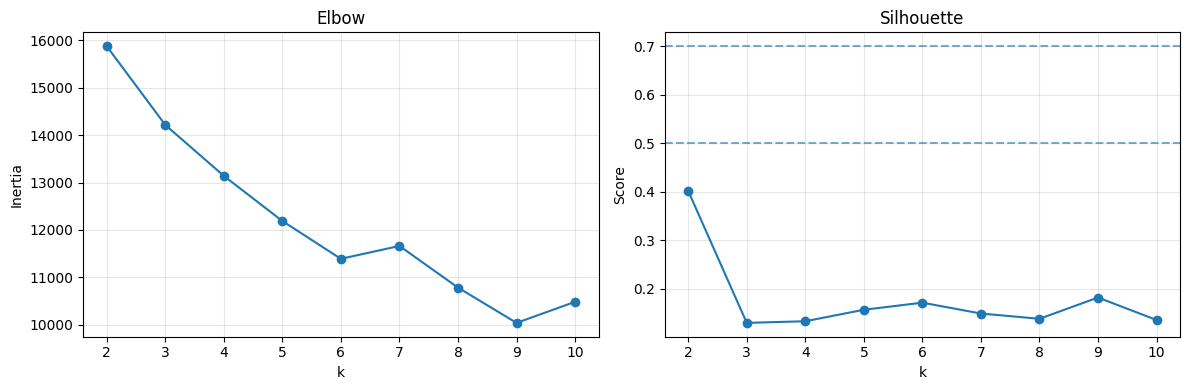

🎯 AUTO-SELECTED k = 2  (raw silhouette = 0.401, min cluster share = 2.7%, penalized score = 0.201)


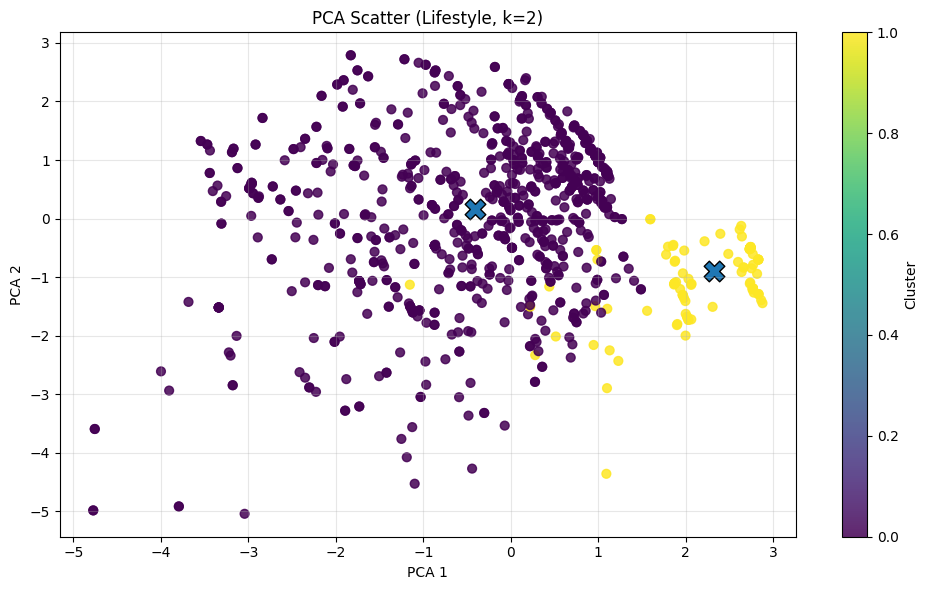

📊 LIFESTYLE — CLUSTER PROFILING

👥 CLUSTER SIZES:
  Cluster 0: 852 (85.0%)
  Cluster 1: 150 (15.0%)

🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):
                                                                                                                                                  Feature      Score      p_value metric
                                                                                      What does the phrase “financially secure life” mean to you? [CQ_02] 565.411530 2.032058e-99      F
                                                                                      What does the phrase “financially secure life” mean to you? [CQ_03] 106.413679 8.862198e-24      F
                                                                                      What does the phrase “financially secure life” mean to you? [CQ_01]  44.555857 4.090482e-11      F
                                                                                                               Respon

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


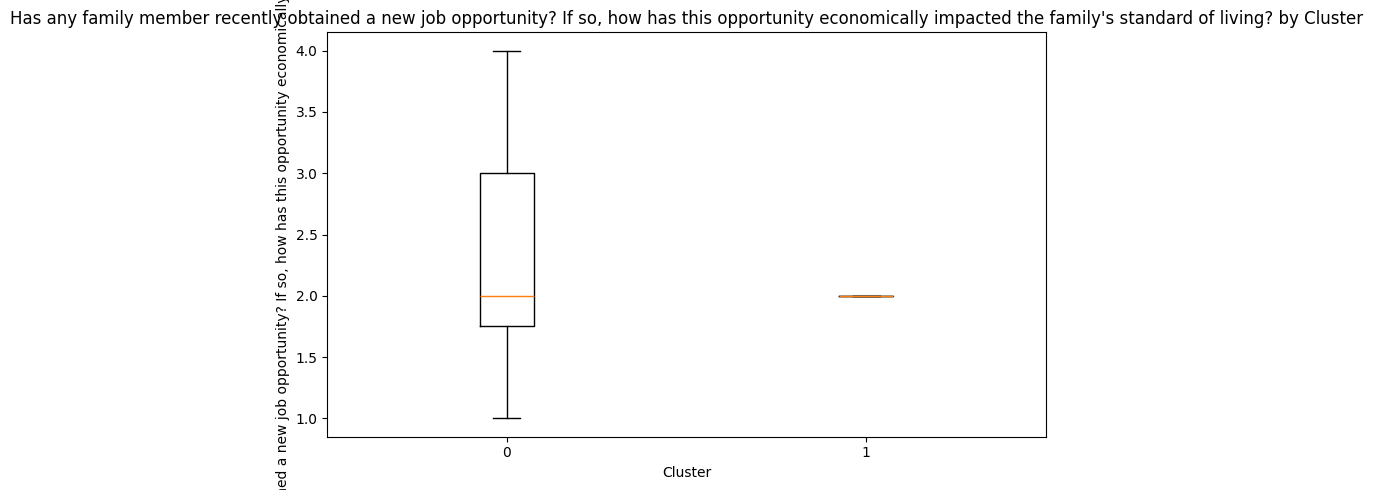

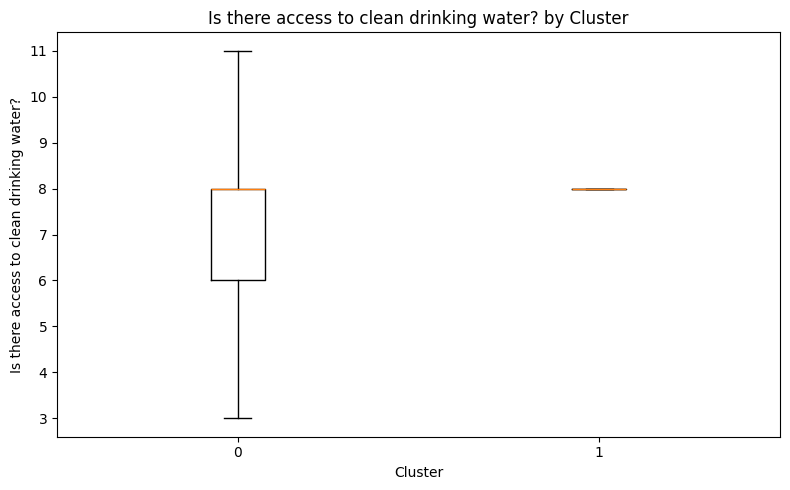

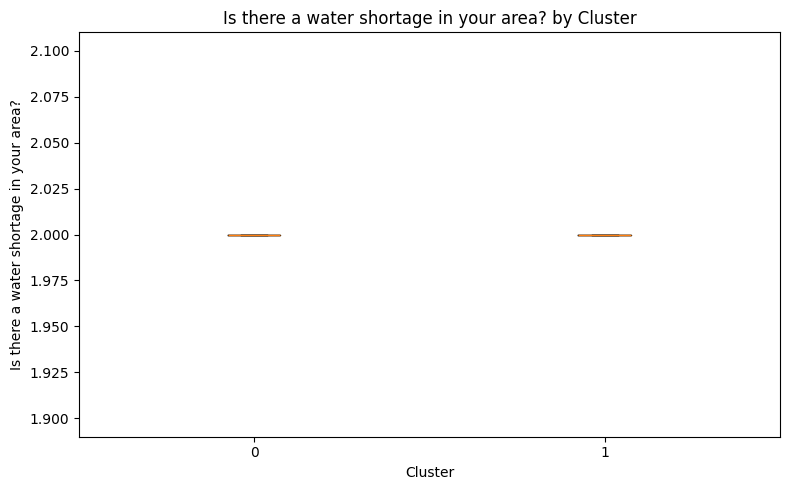

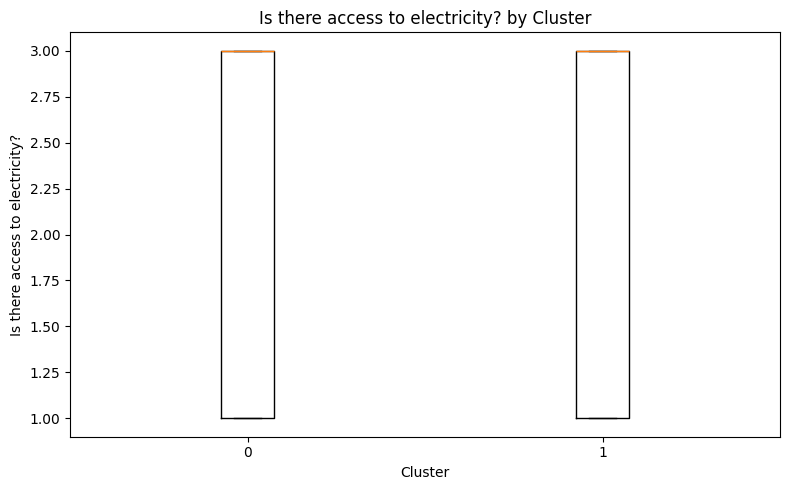

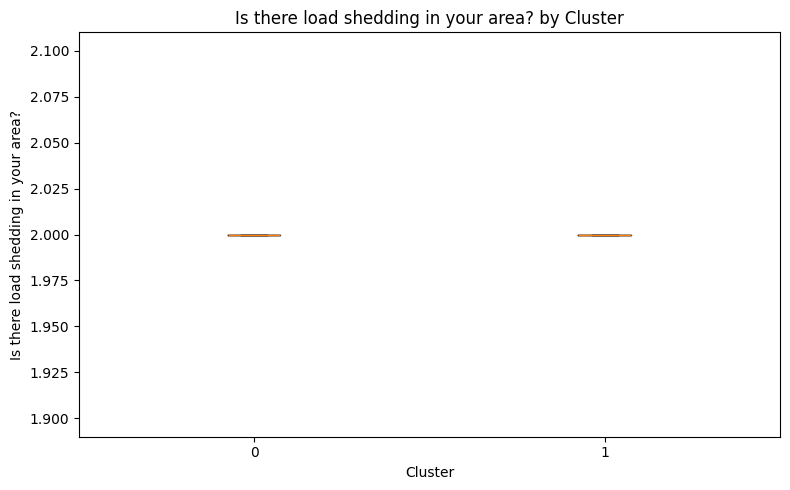

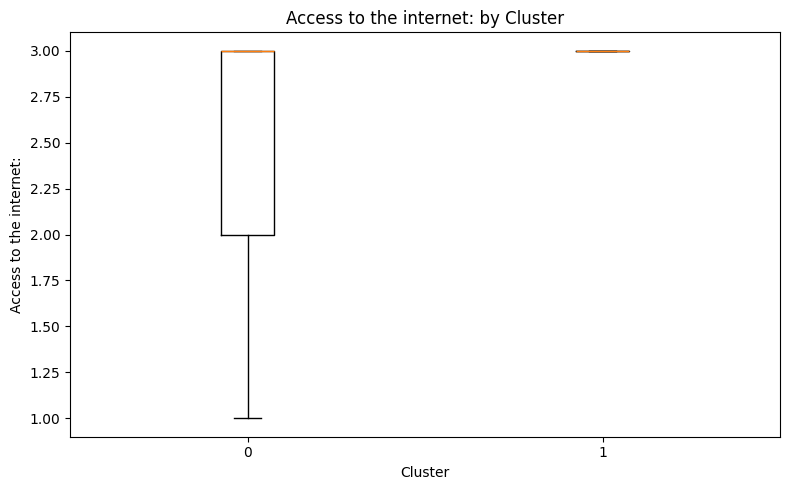

💡 LIFESTYLE — BUSINESS INSIGHTS

📋 CLUSTER 0:
   no strong option-level deviations

📋 CLUSTER 1:
   no strong option-level deviations

📊 Average silhouette score: 0.111

Saved files:
 - clustered_output_Lifestyle.csv
 - anova_top_features_Lifestyle.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for both output files.


In [ ]:
# ============================================================
# Universal Category-wise Clustering & Profiling
# (Interactive upload, English labels, multi-answer aware)
# ============================================================

import os, io, re, math, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Tuple, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import f_classif, chi2

# -----------------------------
# CONFIG (edit if you like)
# -----------------------------
RANDOM_STATE = 42
K_RANGE = range(2, 11)
HIGH_MISSING_THRESH = 0.60

# k-selection guardrails (to avoid tiny, hard-to-interpret clusters)
MIN_CLUSTER_FRAC = 0.03   # reject k if any cluster <3% of samples
PREFER_K_MAX     = 6      # gently penalize k above this for interpretability

# Insights tuning
N_TOP_UP   = 3     # how many higher options to list per base
N_TOP_DOWN = 3     # how many lower options to list per base
EFFECT_PP  = 5.0   # only show lifts with |Δ| >= 5 percentage points

DEFAULT_CATEGORY_NAME = "Category"

# Bases you often want to protect from high-missing drop & narrate against (optional)
DEFAULT_PRIORITY_BASES = ["BR","BK","CE","CH","AB","Y","T"]


# ============================================================
# 0) INTERACTIVE UPLOADS (Colab OR Jupyter)
# ============================================================
def upload_two_excel_files():
    """Return (enc_bytes, key_bytes, enc_name, key_name) from an upload widget."""
    # Try Google Colab
    try:
        from google.colab import files  # type: ignore
        print("Please upload TWO files: (1) Encoded dataset, (2) Key sheet.")
        up = files.upload()
        if len(up) != 2:
            raise ValueError("Please upload exactly two files.")
        names = list(up.keys())
        enc_name, key_name = None, None
        enc_bytes, key_bytes = None, None
        for n in names:
            if "key" in n.lower() or "sheet" in n.lower():
                key_name, key_bytes = n, up[n]
            else:
                enc_name, enc_bytes = n, up[n]
        if not enc_bytes or not key_bytes:
            enc_name, enc_bytes = names[0], up[names[0]]
            key_name, key_bytes = names[1], up[names[1]]
        return io.BytesIO(enc_bytes), io.BytesIO(key_bytes), enc_name, key_name
    except Exception:
        pass

    # Jupyter widgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        up1 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload ENCODED .xlsx")
        up2 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload KEYSHEET .xlsx")
        btn = widgets.Button(description="Continue", button_style="primary")
        out = widgets.Output()
        display(up1, up2, btn, out)
        state = {"done": False, "enc": None, "key": None}
        def _on_click(b):
            with out:
                clear_output()
                if len(up1.value) != 1 or len(up2.value) != 1:
                    print("Please upload exactly one encoded file and one key sheet.")
                    return
                enc_item = list(up1.value.values())[0]
                key_item = list(up2.value.values())[0]
                state["enc"] = (io.BytesIO(enc_item["content"]), enc_item["metadata"]["name"])
                state["key"] = (io.BytesIO(key_item["content"]), key_item["metadata"]["name"])
                state["done"] = True
                print("Files captured. Proceeding…")
        btn.on_click(_on_click)
        while not state["done"]:
            time.sleep(0.2)
        (enc_bytes, enc_name) = state["enc"]
        (key_bytes, key_name) = state["key"]
        return enc_bytes, key_bytes, enc_name, key_name
    except Exception as e:
        raise RuntimeError("Upload widget not available. Please run in Colab/Jupyter.") from e


# ============================================================
# 1) MAPPING & MULTI-ANSWER LOGIC
# ============================================================
RAW_CODE_PAT      = re.compile(r"^([A-Z]+)(\d*)$")     # from raw headers: P, P1, P2…
RENAMED_CODE_PAT  = re.compile(r"\[([A-Z]+)(\d*)\]$")  # from renamed headers: … [P1]

def detect_bases_from_raw(df_raw: pd.DataFrame) -> Dict[str, List[str]]:
    bases = defaultdict(list)
    for c in df_raw.columns.astype(str):
        m = RAW_CODE_PAT.match(c)
        if m:
            bases[m.group(1)].append(c)
    return bases

def build_mapping(df_encoded: pd.DataFrame, key_df: pd.DataFrame) -> Dict[str, str]:
    encoded_cols = set(df_encoded.columns.astype(str))
    best_col, best_overlap = None, -1
    for col in key_df.columns:
        vals = key_df[col].astype(str).str.strip()
        # allow letters+digits in key sheet codes
        overlap = len(set(vals[vals.str.fullmatch(r"[A-Z]{1,3}\d*", na=False)]).intersection(encoded_cols))
        if overlap > best_overlap:
            best_col, best_overlap = col, overlap
    name_col = max([c for c in key_df.columns if c != best_col] or [key_df.columns[0]],
                   key=lambda c: key_df[c].astype(str).str.len().mean())
    mapping = {}
    for code, name in zip(
        key_df[best_col].astype(str).str.strip(),
        key_df[name_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ):
        if code in encoded_cols and name:
            mapping[code] = name
    return mapping

def rename_with_english_and_code(df_raw: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    new_cols = [f"{mapping.get(c,c)} [{c}]" for c in df_raw.columns.astype(str)]
    out = df_raw.copy()
    out.columns = new_cols
    return out

def group_by_base_after_rename(df_named: pd.DataFrame) -> Dict[str, List[str]]:
    by_base = defaultdict(list)
    for col in df_named.columns:
        m = RENAMED_CODE_PAT.search(col)
        if m:
            by_base[m.group(1)].append(col)
    return by_base

def english_stem_for_base(base: str, cols: List[str]) -> str:
    english_parts = [re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip() for c in cols]
    firsts = [p.split(":")[0].split("—")[0].strip() for p in english_parts]
    if len(set(firsts)) == 1:
        return firsts[0]
    return max(set(english_parts), key=english_parts.count) if english_parts else base

def prop(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(np.nanmean(s)) if s.size else np.nan


# ============================================================
# 2) FEATURE PREPARATION (numeric only; keep per-option binaries)
# ============================================================
def maybe_reduce_single_select(num_df: pd.DataFrame, by_base: Dict[str, List[str]],
                               threshold: float = 0.95) -> pd.DataFrame:
    """
    If a 'multi-answer' base is actually single-select (row sum == 1 in >= threshold of rows),
    drop the least prevalent option as a reference to reduce collinearity.
    """
    for b, cols in by_base.items():
        cols = [c for c in cols if c in num_df.columns]
        if len(cols) < 2:
            continue
        sums = num_df[cols].fillna(0).sum(axis=1)
        if (sums == 1).mean() >= threshold:
            prevalences = num_df[cols].mean().sort_values()
            drop_col = prevalences.index[0]
            num_df.drop(columns=[drop_col], inplace=True, errors="ignore")
    return num_df

def prepare_numeric(df_named: pd.DataFrame,
                    by_base: Dict[str, List[str]],
                    priority_bases: Optional[List[str]] = None,
                    high_missing_thresh: float = HIGH_MISSING_THRESH):
    num_df = df_named.select_dtypes(include=[np.number]).copy()
    num_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    all_nan_cols = num_df.columns[num_df.isna().all()].tolist()
    num_df.drop(columns=all_nan_cols, inplace=True, errors="ignore")

    priority_cols = set()
    if priority_bases:
        for b in priority_bases:
            for col in by_base.get(b, []):
                if col in num_df.columns:
                    priority_cols.add(col)

    miss = num_df.isna().mean()
    high_missing_cols = [c for c, m in miss.items() if (m > high_missing_thresh) and (c not in priority_cols)]
    num_df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

    # Optional: de-collinearize disguised single-selects
    num_df = maybe_reduce_single_select(num_df, by_base, threshold=0.95)

    # Drop constants (pre-impute)
    nunique = num_df.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    num_df.drop(columns=const_cols, inplace=True, errors="ignore")

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(num_df)

    # Drop constants AFTER impute (sometimes impute makes a column constant)
    _tmp = pd.DataFrame(X_imputed, columns=num_df.columns)
    const_after = _tmp.nunique(dropna=True)
    const_after_cols = const_after[const_after <= 1].index.tolist()
    if const_after_cols:
        num_df.drop(columns=const_after_cols, inplace=True, errors="ignore")
        X_imputed = SimpleImputer(strategy="median").fit_transform(num_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("=== FEATURE PREPARATION ===")
    print(f"Remaining numeric features: {num_df.shape[1]}")
    print(f"- Dropped all-NaN: {len(all_nan_cols)} | High-missing: {len(high_missing_cols)} "
          f"| Constants pre: {len(const_cols)} | post: {len(const_after_cols)}")

    return num_df, X_imputed, X_scaled


# ============================================================
# 3) k SELECTION with guardrails + FINAL CLUSTERING
# ============================================================
def choose_k_with_guards(X_scaled, k_range=K_RANGE, random_state=RANDOM_STATE,
                         min_cluster_frac=MIN_CLUSTER_FRAC, prefer_k_max=PREFER_K_MAX):
    inertia_list, sil_list, label_sets = [], [], []

    for k in k_range:
        mb = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init=5,
                             batch_size=256, max_iter=100, reassignment_ratio=0.01)
        labels_k = mb.fit_predict(X_scaled)
        label_sets.append(labels_k)
        inertia_list.append(mb.inertia_)
        sil_list.append(silhouette_score(X_scaled, labels_k))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(list(k_range), inertia_list, marker='o'); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.grid(True, alpha=0.3)
    ax2.plot(list(k_range), sil_list, marker='o'); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.5, linestyle='--', alpha=0.6); ax2.axhline(y=0.7, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # Penalize k with tiny clusters or too large k
    n = X_scaled.shape[0]
    candidates = []
    for k, sil, labels in zip(k_range, sil_list, label_sets):
        counts = np.bincount(labels)
        smallest_frac = counts.min() / n
        penalty = 0.0
        if k > prefer_k_max:       penalty += 0.02 * (k - prefer_k_max)   # gentle k penalty
        if smallest_frac < min_cluster_frac: penalty += 0.20              # strong tiny-cluster penalty
        candidates.append((k, sil - penalty, sil, smallest_frac))
    best_k, penalized, raw_sil, min_frac = max(candidates, key=lambda t: t[1])
    print(f"🎯 AUTO-SELECTED k = {best_k}  (raw silhouette = {raw_sil:.3f}, "
          f"min cluster share = {min_frac*100:.1f}%, penalized score = {penalized:.3f})")
    return best_k, inertia_list, sil_list

def run_kmeans(X_scaled, best_k, random_state=RANDOM_STATE):
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_scaled)
    return km, labels


# ============================================================
# 4) PCA + PROFILING (ANOVA/χ²) + INSIGHTS
# ============================================================
def plot_pca(X_scaled, labels, kmeans, category):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40, alpha=0.85)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=220, edgecolor='k')
    plt.title(f"PCA Scatter ({category}, k={kmeans.n_clusters})")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.colorbar(sc, label="Cluster"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return pca, X_pca, centroids_pca

def rank_features_discriminative(X_imp_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    # Try ANOVA F first
    try:
        F, p = f_classif(X_imp_df, labels)
        df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": F, "p_value": p, "metric": "F"})
        return df.replace([np.inf, -np.inf], np.nan)
    except Exception:
        pass
    # Fallback to chi-square (requires non-negative)
    X_nonneg = (X_imp_df - X_imp_df.min()).clip(lower=0.0)
    chi, p = chi2(X_nonneg, labels)
    df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": chi, "p_value": p, "metric": "chi2"})
    return df.replace([np.inf, -np.inf], np.nan)

def profile_clusters(category, df_named, num_df, X_imputed, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    print("="*60); print(f"📊 {category.upper()} — CLUSTER PROFILING"); print("="*60)
    sizes = df["Cluster"].value_counts().sort_index()
    total = len(df)
    print("\n👥 CLUSTER SIZES:")
    for cid, sz in sizes.items():
        print(f"  Cluster {cid}: {sz} ({sz/total*100:.1f}%)")

    X_imp_df = pd.DataFrame(X_imputed, columns=num_df.columns, index=df.index)
    ranked = rank_features_discriminative(X_imp_df, df["Cluster"])
    anova = (ranked.dropna(subset=["Score","p_value"])
                   .sort_values("Score", ascending=False)
                   .reset_index(drop=True))
    print("\n🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):")
    print(anova.head(12).to_string(index=False))

    # Boxplots (up to 6 features)
    feats = list(num_df.columns)[:6]
    for feat in feats:
        data_by_cluster = [df.loc[df["Cluster"]==c, feat].dropna().values for c in sorted(df["Cluster"].unique())]
        plt.figure(figsize=(8,5))
        plt.boxplot(data_by_cluster, tick_labels=[str(c) for c in sorted(df["Cluster"].unique())], showfliers=False)
        label = re.sub(r"\s*\[[^\]]+\]\s*$","", feat)
        plt.title(f"{label} by Cluster"); plt.xlabel("Cluster"); plt.ylabel(label)
        plt.tight_layout(); plt.show()

    return sizes, anova

def business_insights(category, df_named, num_df, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    by_base = group_by_base_after_rename(df_named)
    base_stem = {b: english_stem_for_base(b, cols) for b, cols in by_base.items()}
    overall = df.mean(numeric_only=True)

    print("="*60); print(f"💡 {category.upper()} — BUSINESS INSIGHTS"); print("="*60)

    def clean_label(col: str) -> str:
        return re.sub(r"\s*\[[^\]]+\]\s*$", "", col).strip()

    for cid in sorted(df["Cluster"].unique()):
        seg = df[df["Cluster"]==cid]
        print(f"\n📋 CLUSTER {cid}:")
        notes = []
        for b, cols in by_base.items():
            cols = [c for c in cols if c in num_df.columns]
            if len(cols) <= 1:
                continue

            # Option-level lifts with effect-size threshold
            lifts = []
            for col in cols:
                seg_p = prop(seg[col]); all_p = prop(df[col])
                if np.isnan(seg_p) or np.isnan(all_p):
                    continue
                diff_pp = (seg_p - all_p) * 100
                if abs(diff_pp) >= EFFECT_PP:
                    lifts.append((col, diff_pp, seg_p, all_p))
            if not lifts:
                continue

            lifts_sorted = sorted(lifts, key=lambda x: x[1], reverse=True)
            up   = [f"{clean_label(c)} (+{dpp:.0f} pp)" for c,dpp,_,_ in lifts_sorted if dpp > 0][:N_TOP_UP]
            down = [f"{clean_label(c)} ({dpp:.0f} pp)"  for c,dpp,_,_ in reversed(lifts_sorted) if dpp < 0][:N_TOP_DOWN]

            # “Any — stem” only if informative
            any_name = f"Any — {base_stem[b]} [{b}_ANY]"
            df[any_name] = (df[cols].fillna(0) > 0).any(axis=1).astype(int)
            seg_any = df.loc[df["Cluster"]==cid, any_name].mean()*100
            all_any = df[any_name].mean()*100
            any_txt = f"; Any: {seg_any:.0f}% vs {all_any:.0f}%" if (1.0 < all_any < 99.0) else ""

            if up or down:
                parts = []
                if up: parts.append(", ".join(up))
                if down: parts.append(", ".join(down))
                notes.append(f"{base_stem[b]} ↑/↓: {'; '.join(parts)}{any_txt}")

        print("   " + ("; ".join(notes) if notes else "no strong option-level deviations"))


# ============================================================
# 5) MAIN RUNNER (ONE CATEGORY)
# ============================================================
def run_category_pipeline(category_name: str,
                          enc_bytes: io.BytesIO,
                          key_bytes: io.BytesIO,
                          priority_bases: Optional[List[str]] = None):
    # Load
    df_raw = pd.read_excel(enc_bytes, sheet_name=0)
    key_df = pd.read_excel(key_bytes, sheet_name=0)

    # Detect bases from raw (P1,P2,… → base P). Optionally use as priority bases.
    raw_bases = detect_bases_from_raw(df_raw)
    if priority_bases is None:
        # protect EVERYTHING present in this category + some global defaults
        priority_bases = sorted(set(raw_bases.keys()).union(DEFAULT_PRIORITY_BASES))

    # Map & rename to English [CODE]
    mapping = build_mapping(df_raw, key_df)
    df_named = rename_with_english_and_code(df_raw, mapping)

    # Group by base after rename
    by_base = group_by_base_after_rename(df_named)

    # Feature prep
    num_df, X_imputed, X_scaled = prepare_numeric(
        df_named, by_base, priority_bases=priority_bases, high_missing_thresh=HIGH_MISSING_THRESH
    )
    if num_df.shape[1] == 0:
        print("❌ No numeric features left after cleaning.")
        return df_named

    # k-selection (guarded) + final KMeans
    best_k, _, _ = choose_k_with_guards(X_scaled, k_range=K_RANGE)
    kmeans, labels = run_kmeans(X_scaled, best_k)

    # PCA
    plot_pca(X_scaled, labels, kmeans, category_name)

    # Profiling + insights
    sizes, anova = profile_clusters(category_name, df_named, num_df, X_imputed, labels)
    business_insights(category_name, df_named, num_df, labels)

    # Silhouette per-sample
    try:
        sil = silhouette_samples(X_scaled, labels)
        avg_sil = sil.mean()
    except Exception as e:
        sil = np.full(shape=(len(df_named),), fill_value=np.nan)
        avg_sil = np.nan
        print("⚠️  Could not compute silhouette per-sample:", e)

    # Output DF
    df_out = df_named.copy()
    df_out["Cluster"] = labels
    df_out["Silhouette_Score"] = sil
    print(f"\n📊 Average silhouette score: {avg_sil:.3f}")

    # Save
    safe_cat = re.sub(r"[^A-Za-z0-9_-]+", "_", category_name.strip() or "Category")
    out_csv = f"clustered_output_{safe_cat}.csv"
    anova_csv = f"anova_top_features_{safe_cat}.csv"
    df_out.to_csv(out_csv, index=False)
    anova.to_csv(anova_csv, index=False)
    print("\nSaved files:")
    print(" -", out_csv)
    print(" -", anova_csv)

    # -----------------------------
    # AUTO-DOWNLOAD (Colab only)
    # -----------------------------
    try:
        from google.colab import files  # type: ignore
        files.download(out_csv)
        files.download(anova_csv)
        print("⬇️ Download started for both output files.")
    except Exception:
        pass

    return df_out


# ============================================================
# 6) GO: Ask, Upload, Run
# ============================================================
category_name = input(f"Enter category name (default '{DEFAULT_CATEGORY_NAME}'): ").strip() or DEFAULT_CATEGORY_NAME
enc_bytes, key_bytes, enc_name, key_name = upload_two_excel_files()
print(f"\n✅ Encoded: {enc_name}\n✅ Keysheet: {key_name}\nCategory: {category_name}")

df_with_clusters = run_category_pipeline(
    category_name=category_name,
    enc_bytes=enc_bytes,
    key_bytes=key_bytes,
    # priority_bases=None  # leave as None to auto-protect all bases + defaults
)


Enter category name (default 'Category'): Occupation
Please upload TWO files: (1) Encoded dataset, (2) Key sheet.


Saving Occupation_encoded_dataset.xlsx to Occupation_encoded_dataset.xlsx
Saving Occupation_key_sheet.xlsx to Occupation_key_sheet.xlsx

✅ Encoded: Occupation_encoded_dataset.xlsx
✅ Keysheet: Occupation_key_sheet.xlsx
Category: Occupation
=== FEATURE PREPARATION ===
Remaining numeric features: 10
- Dropped all-NaN: 0 | High-missing: 0 | Constants pre: 0 | post: 0


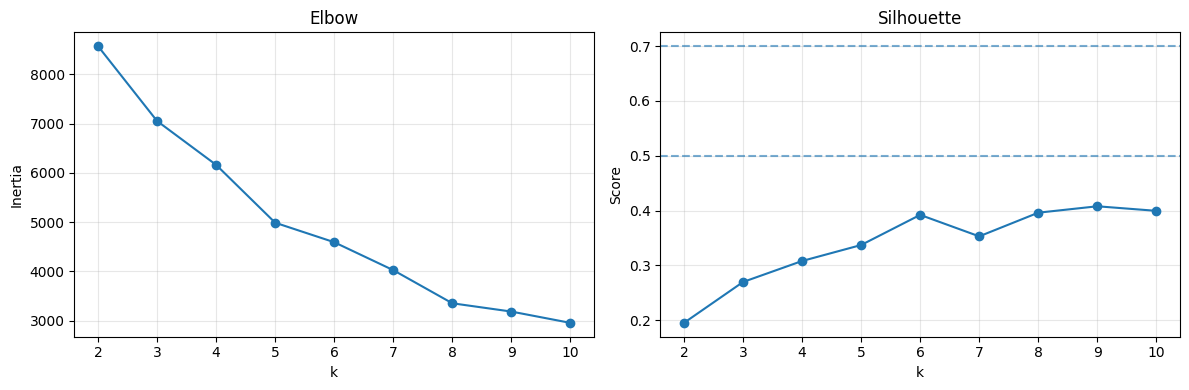

🎯 AUTO-SELECTED k = 6  (raw silhouette = 0.392, min cluster share = 11.6%, penalized score = 0.392)


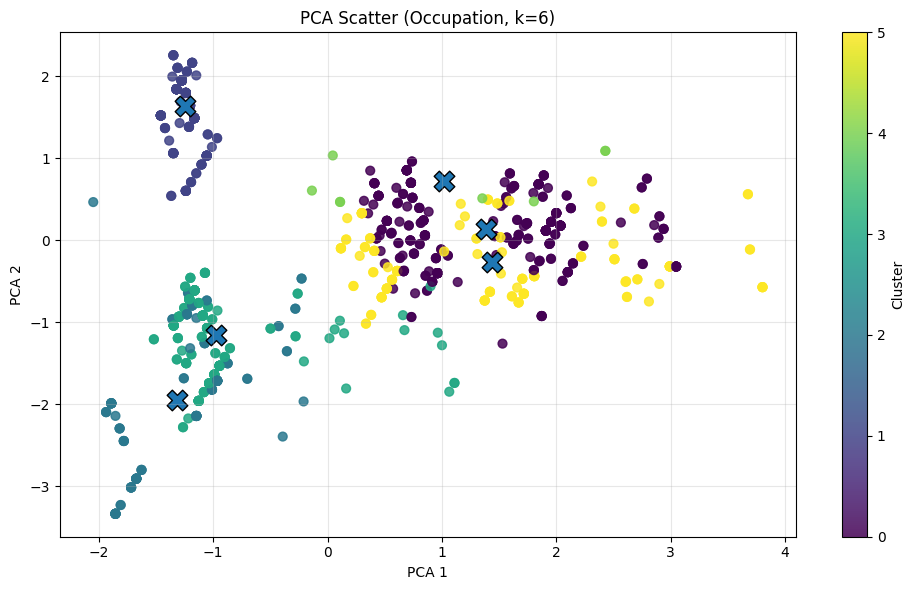

📊 OCCUPATION — CLUSTER PROFILING

👥 CLUSTER SIZES:
  Cluster 0: 311 (31.0%)
  Cluster 1: 253 (25.2%)
  Cluster 2: 116 (11.6%)
  Cluster 3: 175 (17.5%)
  Cluster 4: 8 (0.8%)
  Cluster 5: 139 (13.9%)

🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):
                                            Feature        Score       p_value metric
                                      AP_04 [AP_04] 37900.106972  0.000000e+00      F
                                      AP_06 [AP_06]  2267.393524  0.000000e+00      F
                                      AP_05 [AP_05]   921.542476  0.000000e+00      F
                                      AP_08 [AP_08]   146.858782 8.254416e-117      F
                                      AP_01 [AP_01]   115.000555  5.109375e-96      F
                                      AP_03 [AP_03]    44.268834  2.608979e-41      F
Family breadwinner's main occupation. Member 1: [J]    16.994905  3.761080e-16      F
                                      Member 2: [K]     6.388734  7.497

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: divide by zero encountered in divide
  f = msb / msw


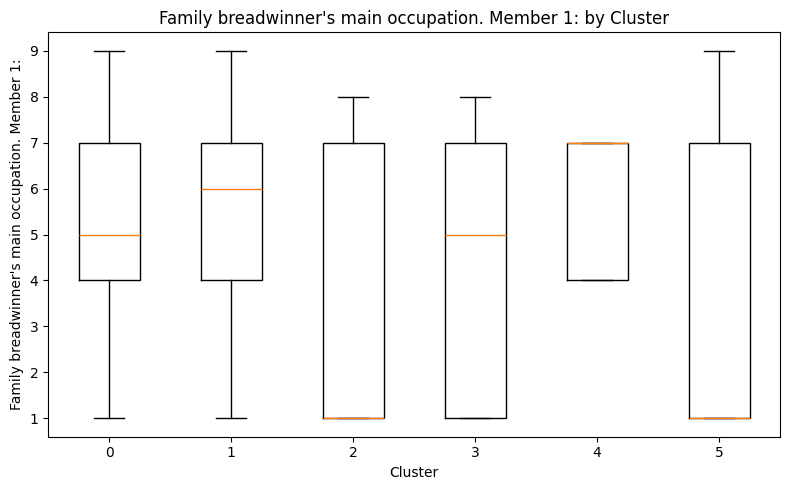

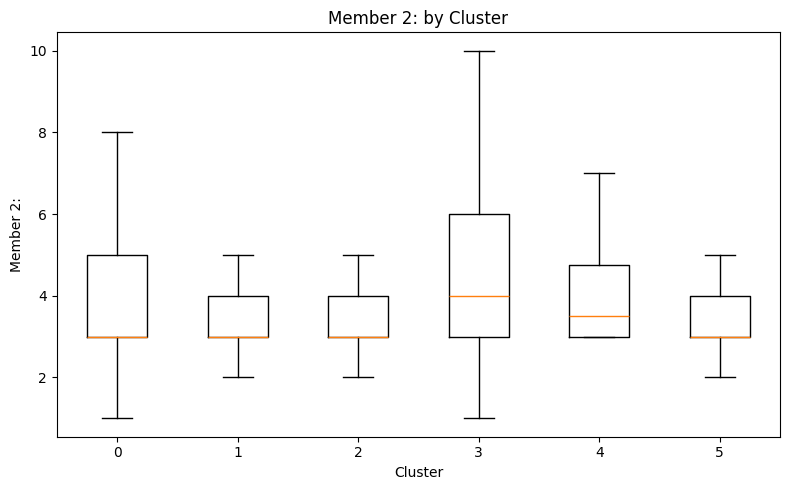

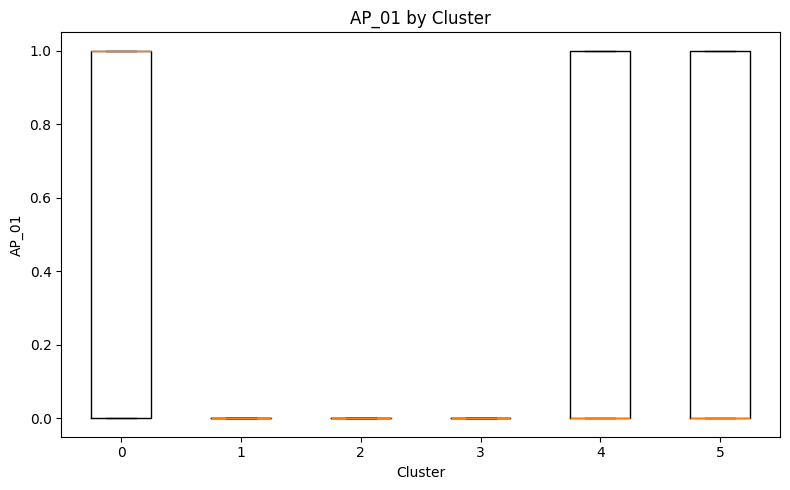

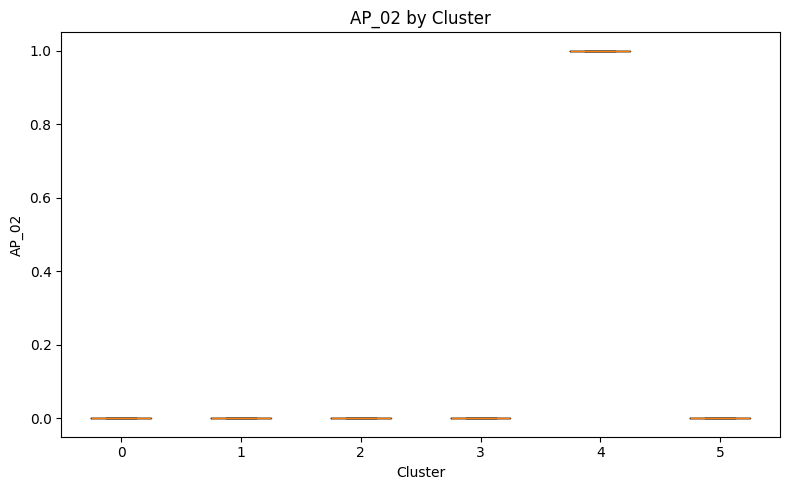

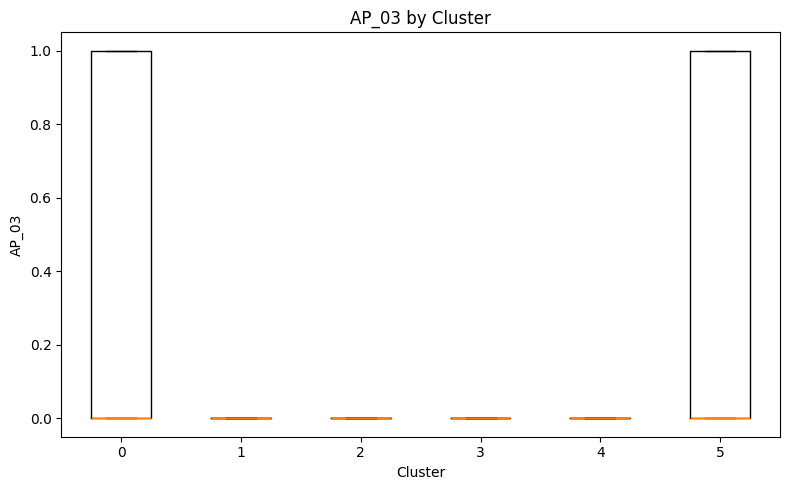

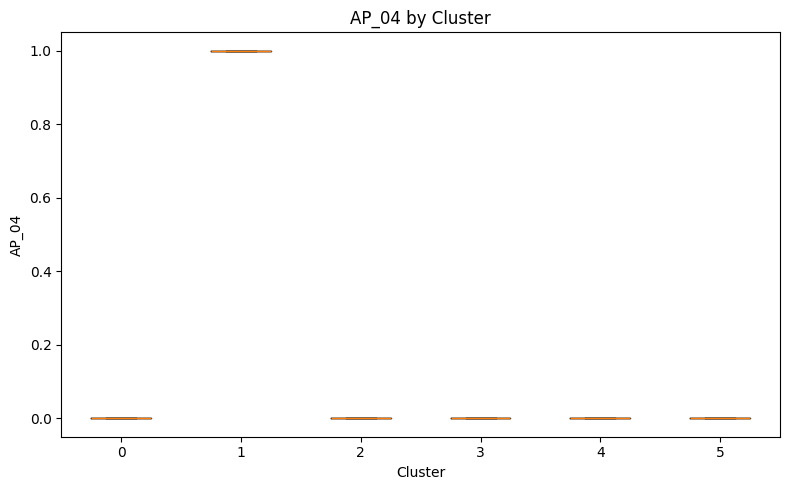

💡 OCCUPATION — BUSINESS INSIGHTS

📋 CLUSTER 0:
   no strong option-level deviations

📋 CLUSTER 1:
   no strong option-level deviations

📋 CLUSTER 2:
   no strong option-level deviations

📋 CLUSTER 3:
   no strong option-level deviations

📋 CLUSTER 4:
   no strong option-level deviations

📋 CLUSTER 5:
   no strong option-level deviations

📊 Average silhouette score: 0.383

Saved files:
 - clustered_output_Occupation.csv
 - anova_top_features_Occupation.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️ Download started for both output files.


In [ ]:
# ============================================================
# Universal Category-wise Clustering & Profiling
# (Interactive upload, English labels, multi-answer aware)
# ============================================================

import os, io, re, math, sys, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import defaultdict
from typing import Dict, List, Tuple, Optional

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.feature_selection import f_classif, chi2

# -----------------------------
# CONFIG (edit if you like)
# -----------------------------
RANDOM_STATE = 42
K_RANGE = range(2, 11)
HIGH_MISSING_THRESH = 0.60

# k-selection guardrails (to avoid tiny, hard-to-interpret clusters)
MIN_CLUSTER_FRAC = 0.03   # reject k if any cluster <3% of samples
PREFER_K_MAX     = 6      # gently penalize k above this for interpretability

# Insights tuning
N_TOP_UP   = 3     # how many higher options to list per base
N_TOP_DOWN = 3     # how many lower options to list per base
EFFECT_PP  = 5.0   # only show lifts with |Δ| >= 5 percentage points

DEFAULT_CATEGORY_NAME = "Category"

# Bases you often want to protect from high-missing drop & narrate against (optional)
DEFAULT_PRIORITY_BASES = ["BR","BK","CE","CH","AB","Y","T"]


# ============================================================
# 0) INTERACTIVE UPLOADS (Colab OR Jupyter)
# ============================================================
def upload_two_excel_files():
    """Return (enc_bytes, key_bytes, enc_name, key_name) from an upload widget."""
    # Try Google Colab
    try:
        from google.colab import files  # type: ignore
        print("Please upload TWO files: (1) Encoded dataset, (2) Key sheet.")
        up = files.upload()
        if len(up) != 2:
            raise ValueError("Please upload exactly two files.")
        names = list(up.keys())
        enc_name, key_name = None, None
        enc_bytes, key_bytes = None, None
        for n in names:
            if "key" in n.lower() or "sheet" in n.lower():
                key_name, key_bytes = n, up[n]
            else:
                enc_name, enc_bytes = n, up[n]
        if not enc_bytes or not key_bytes:
            enc_name, enc_bytes = names[0], up[names[0]]
            key_name, key_bytes = names[1], up[names[1]]
        return io.BytesIO(enc_bytes), io.BytesIO(key_bytes), enc_name, key_name
    except Exception:
        pass

    # Jupyter widgets
    try:
        import ipywidgets as widgets
        from IPython.display import display, clear_output
        up1 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload ENCODED .xlsx")
        up2 = widgets.FileUpload(accept=".xlsx", multiple=False, description="Upload KEYSHEET .xlsx")
        btn = widgets.Button(description="Continue", button_style="primary")
        out = widgets.Output()
        display(up1, up2, btn, out)
        state = {"done": False, "enc": None, "key": None}
        def _on_click(b):
            with out:
                clear_output()
                if len(up1.value) != 1 or len(up2.value) != 1:
                    print("Please upload exactly one encoded file and one key sheet.")
                    return
                enc_item = list(up1.value.values())[0]
                key_item = list(up2.value.values())[0]
                state["enc"] = (io.BytesIO(enc_item["content"]), enc_item["metadata"]["name"])
                state["key"] = (io.BytesIO(key_item["content"]), key_item["metadata"]["name"])
                state["done"] = True
                print("Files captured. Proceeding…")
        btn.on_click(_on_click)
        while not state["done"]:
            time.sleep(0.2)
        (enc_bytes, enc_name) = state["enc"]
        (key_bytes, key_name) = state["key"]
        return enc_bytes, key_bytes, enc_name, key_name
    except Exception as e:
        raise RuntimeError("Upload widget not available. Please run in Colab/Jupyter.") from e


# ============================================================
# 1) MAPPING & MULTI-ANSWER LOGIC
# ============================================================
RAW_CODE_PAT      = re.compile(r"^([A-Z]+)(\d*)$")     # from raw headers: P, P1, P2…
RENAMED_CODE_PAT  = re.compile(r"\[([A-Z]+)(\d*)\]$")  # from renamed headers: … [P1]

def detect_bases_from_raw(df_raw: pd.DataFrame) -> Dict[str, List[str]]:
    bases = defaultdict(list)
    for c in df_raw.columns.astype(str):
        m = RAW_CODE_PAT.match(c)
        if m:
            bases[m.group(1)].append(c)
    return bases

def build_mapping(df_encoded: pd.DataFrame, key_df: pd.DataFrame) -> Dict[str, str]:
    encoded_cols = set(df_encoded.columns.astype(str))
    best_col, best_overlap = None, -1
    for col in key_df.columns:
        vals = key_df[col].astype(str).str.strip()
        # allow letters+digits in key sheet codes
        overlap = len(set(vals[vals.str.fullmatch(r"[A-Z]{1,3}\d*", na=False)]).intersection(encoded_cols))
        if overlap > best_overlap:
            best_col, best_overlap = col, overlap
    name_col = max([c for c in key_df.columns if c != best_col] or [key_df.columns[0]],
                   key=lambda c: key_df[c].astype(str).str.len().mean())
    mapping = {}
    for code, name in zip(
        key_df[best_col].astype(str).str.strip(),
        key_df[name_col].astype(str).str.replace(r"\s+", " ", regex=True).str.strip()
    ):
        if code in encoded_cols and name:
            mapping[code] = name
    return mapping

def rename_with_english_and_code(df_raw: pd.DataFrame, mapping: Dict[str, str]) -> pd.DataFrame:
    new_cols = [f"{mapping.get(c,c)} [{c}]" for c in df_raw.columns.astype(str)]
    out = df_raw.copy()
    out.columns = new_cols
    return out

def group_by_base_after_rename(df_named: pd.DataFrame) -> Dict[str, List[str]]:
    by_base = defaultdict(list)
    for col in df_named.columns:
        m = RENAMED_CODE_PAT.search(col)
        if m:
            by_base[m.group(1)].append(col)
    return by_base

def english_stem_for_base(base: str, cols: List[str]) -> str:
    english_parts = [re.sub(r"\s*\[[^\]]+\]\s*$", "", c).strip() for c in cols]
    firsts = [p.split(":")[0].split("—")[0].strip() for p in english_parts]
    if len(set(firsts)) == 1:
        return firsts[0]
    return max(set(english_parts), key=english_parts.count) if english_parts else base

def prop(series: pd.Series) -> float:
    s = pd.to_numeric(series, errors="coerce")
    return float(np.nanmean(s)) if s.size else np.nan


# ============================================================
# 2) FEATURE PREPARATION (numeric only; keep per-option binaries)
# ============================================================
def maybe_reduce_single_select(num_df: pd.DataFrame, by_base: Dict[str, List[str]],
                               threshold: float = 0.95) -> pd.DataFrame:
    """
    If a 'multi-answer' base is actually single-select (row sum == 1 in >= threshold of rows),
    drop the least prevalent option as a reference to reduce collinearity.
    """
    for b, cols in by_base.items():
        cols = [c for c in cols if c in num_df.columns]
        if len(cols) < 2:
            continue
        sums = num_df[cols].fillna(0).sum(axis=1)
        if (sums == 1).mean() >= threshold:
            prevalences = num_df[cols].mean().sort_values()
            drop_col = prevalences.index[0]
            num_df.drop(columns=[drop_col], inplace=True, errors="ignore")
    return num_df

def prepare_numeric(df_named: pd.DataFrame,
                    by_base: Dict[str, List[str]],
                    priority_bases: Optional[List[str]] = None,
                    high_missing_thresh: float = HIGH_MISSING_THRESH):
    num_df = df_named.select_dtypes(include=[np.number]).copy()
    num_df.replace([np.inf, -np.inf], np.nan, inplace=True)

    all_nan_cols = num_df.columns[num_df.isna().all()].tolist()
    num_df.drop(columns=all_nan_cols, inplace=True, errors="ignore")

    priority_cols = set()
    if priority_bases:
        for b in priority_bases:
            for col in by_base.get(b, []):
                if col in num_df.columns:
                    priority_cols.add(col)

    miss = num_df.isna().mean()
    high_missing_cols = [c for c, m in miss.items() if (m > high_missing_thresh) and (c not in priority_cols)]
    num_df.drop(columns=high_missing_cols, inplace=True, errors="ignore")

    # Optional: de-collinearize disguised single-selects
    num_df = maybe_reduce_single_select(num_df, by_base, threshold=0.95)

    # Drop constants (pre-impute)
    nunique = num_df.nunique(dropna=True)
    const_cols = nunique[nunique <= 1].index.tolist()
    num_df.drop(columns=const_cols, inplace=True, errors="ignore")

    imputer = SimpleImputer(strategy="median")
    X_imputed = imputer.fit_transform(num_df)

    # Drop constants AFTER impute (sometimes impute makes a column constant)
    _tmp = pd.DataFrame(X_imputed, columns=num_df.columns)
    const_after = _tmp.nunique(dropna=True)
    const_after_cols = const_after[const_after <= 1].index.tolist()
    if const_after_cols:
        num_df.drop(columns=const_after_cols, inplace=True, errors="ignore")
        X_imputed = SimpleImputer(strategy="median").fit_transform(num_df)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_imputed)

    print("=== FEATURE PREPARATION ===")
    print(f"Remaining numeric features: {num_df.shape[1]}")
    print(f"- Dropped all-NaN: {len(all_nan_cols)} | High-missing: {len(high_missing_cols)} "
          f"| Constants pre: {len(const_cols)} | post: {len(const_after_cols)}")

    return num_df, X_imputed, X_scaled


# ============================================================
# 3) k SELECTION with guardrails + FINAL CLUSTERING
# ============================================================
def choose_k_with_guards(X_scaled, k_range=K_RANGE, random_state=RANDOM_STATE,
                         min_cluster_frac=MIN_CLUSTER_FRAC, prefer_k_max=PREFER_K_MAX):
    inertia_list, sil_list, label_sets = [], [], []

    for k in k_range:
        mb = MiniBatchKMeans(n_clusters=k, random_state=random_state, n_init=5,
                             batch_size=256, max_iter=100, reassignment_ratio=0.01)
        labels_k = mb.fit_predict(X_scaled)
        label_sets.append(labels_k)
        inertia_list.append(mb.inertia_)
        sil_list.append(silhouette_score(X_scaled, labels_k))

    # Plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))
    ax1.plot(list(k_range), inertia_list, marker='o'); ax1.set_title('Elbow'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia'); ax1.grid(True, alpha=0.3)
    ax2.plot(list(k_range), sil_list, marker='o'); ax2.set_title('Silhouette'); ax2.set_xlabel('k'); ax2.set_ylabel('Score'); ax2.grid(True, alpha=0.3)
    ax2.axhline(y=0.5, linestyle='--', alpha=0.6); ax2.axhline(y=0.7, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # Penalize k with tiny clusters or too large k
    n = X_scaled.shape[0]
    candidates = []
    for k, sil, labels in zip(k_range, sil_list, label_sets):
        counts = np.bincount(labels)
        smallest_frac = counts.min() / n
        penalty = 0.0
        if k > prefer_k_max:       penalty += 0.02 * (k - prefer_k_max)   # gentle k penalty
        if smallest_frac < min_cluster_frac: penalty += 0.20              # strong tiny-cluster penalty
        candidates.append((k, sil - penalty, sil, smallest_frac))
    best_k, penalized, raw_sil, min_frac = max(candidates, key=lambda t: t[1])
    print(f"🎯 AUTO-SELECTED k = {best_k}  (raw silhouette = {raw_sil:.3f}, "
          f"min cluster share = {min_frac*100:.1f}%, penalized score = {penalized:.3f})")
    return best_k, inertia_list, sil_list

def run_kmeans(X_scaled, best_k, random_state=RANDOM_STATE):
    km = KMeans(n_clusters=best_k, random_state=random_state, n_init=10)
    labels = km.fit_predict(X_scaled)
    return km, labels


# ============================================================
# 4) PCA + PROFILING (ANOVA/χ²) + INSIGHTS
# ============================================================
def plot_pca(X_scaled, labels, kmeans, category):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    X_pca = pca.fit_transform(X_scaled)
    centroids_pca = pca.transform(kmeans.cluster_centers_)
    plt.figure(figsize=(10,6))
    sc = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, s=40, alpha=0.85)
    plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='X', s=220, edgecolor='k')
    plt.title(f"PCA Scatter ({category}, k={kmeans.n_clusters})")
    plt.xlabel("PCA 1"); plt.ylabel("PCA 2"); plt.colorbar(sc, label="Cluster"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    return pca, X_pca, centroids_pca

def rank_features_discriminative(X_imp_df: pd.DataFrame, labels: np.ndarray) -> pd.DataFrame:
    # Try ANOVA F first
    try:
        F, p = f_classif(X_imp_df, labels)
        df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": F, "p_value": p, "metric": "F"})
        return df.replace([np.inf, -np.inf], np.nan)
    except Exception:
        pass
    # Fallback to chi-square (requires non-negative)
    X_nonneg = (X_imp_df - X_imp_df.min()).clip(lower=0.0)
    chi, p = chi2(X_nonneg, labels)
    df = pd.DataFrame({"Feature": X_imp_df.columns, "Score": chi, "p_value": p, "metric": "chi2"})
    return df.replace([np.inf, -np.inf], np.nan)

def profile_clusters(category, df_named, num_df, X_imputed, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    print("="*60); print(f"📊 {category.upper()} — CLUSTER PROFILING"); print("="*60)
    sizes = df["Cluster"].value_counts().sort_index()
    total = len(df)
    print("\n👥 CLUSTER SIZES:")
    for cid, sz in sizes.items():
        print(f"  Cluster {cid}: {sz} ({sz/total*100:.1f}%)")

    X_imp_df = pd.DataFrame(X_imputed, columns=num_df.columns, index=df.index)
    ranked = rank_features_discriminative(X_imp_df, df["Cluster"])
    anova = (ranked.dropna(subset=["Score","p_value"])
                   .sort_values("Score", ascending=False)
                   .reset_index(drop=True))
    print("\n🔍 TOP DISCRIMINATING FEATURES (ANOVA/χ²):")
    print(anova.head(12).to_string(index=False))

    # Boxplots (up to 6 features)
    feats = list(num_df.columns)[:6]
    for feat in feats:
        data_by_cluster = [df.loc[df["Cluster"]==c, feat].dropna().values for c in sorted(df["Cluster"].unique())]
        plt.figure(figsize=(8,5))
        plt.boxplot(data_by_cluster, tick_labels=[str(c) for c in sorted(df["Cluster"].unique())], showfliers=False)
        label = re.sub(r"\s*\[[^\]]+\]\s*$","", feat)
        plt.title(f"{label} by Cluster"); plt.xlabel("Cluster"); plt.ylabel(label)
        plt.tight_layout(); plt.show()

    return sizes, anova

def business_insights(category, df_named, num_df, labels):
    df = df_named.copy()
    df["Cluster"] = labels

    by_base = group_by_base_after_rename(df_named)
    base_stem = {b: english_stem_for_base(b, cols) for b, cols in by_base.items()}
    overall = df.mean(numeric_only=True)

    print("="*60); print(f"💡 {category.upper()} — BUSINESS INSIGHTS"); print("="*60)

    def clean_label(col: str) -> str:
        return re.sub(r"\s*\[[^\]]+\]\s*$", "", col).strip()

    for cid in sorted(df["Cluster"].unique()):
        seg = df[df["Cluster"]==cid]
        print(f"\n📋 CLUSTER {cid}:")
        notes = []
        for b, cols in by_base.items():
            cols = [c for c in cols if c in num_df.columns]
            if len(cols) <= 1:
                continue

            # Option-level lifts with effect-size threshold
            lifts = []
            for col in cols:
                seg_p = prop(seg[col]); all_p = prop(df[col])
                if np.isnan(seg_p) or np.isnan(all_p):
                    continue
                diff_pp = (seg_p - all_p) * 100
                if abs(diff_pp) >= EFFECT_PP:
                    lifts.append((col, diff_pp, seg_p, all_p))
            if not lifts:
                continue

            lifts_sorted = sorted(lifts, key=lambda x: x[1], reverse=True)
            up   = [f"{clean_label(c)} (+{dpp:.0f} pp)" for c,dpp,_,_ in lifts_sorted if dpp > 0][:N_TOP_UP]
            down = [f"{clean_label(c)} ({dpp:.0f} pp)"  for c,dpp,_,_ in reversed(lifts_sorted) if dpp < 0][:N_TOP_DOWN]

            # “Any — stem” only if informative
            any_name = f"Any — {base_stem[b]} [{b}_ANY]"
            df[any_name] = (df[cols].fillna(0) > 0).any(axis=1).astype(int)
            seg_any = df.loc[df["Cluster"]==cid, any_name].mean()*100
            all_any = df[any_name].mean()*100
            any_txt = f"; Any: {seg_any:.0f}% vs {all_any:.0f}%" if (1.0 < all_any < 99.0) else ""

            if up or down:
                parts = []
                if up: parts.append(", ".join(up))
                if down: parts.append(", ".join(down))
                notes.append(f"{base_stem[b]} ↑/↓: {'; '.join(parts)}{any_txt}")

        print("   " + ("; ".join(notes) if notes else "no strong option-level deviations"))


# ============================================================
# 5) MAIN RUNNER (ONE CATEGORY)
# ============================================================
def run_category_pipeline(category_name: str,
                          enc_bytes: io.BytesIO,
                          key_bytes: io.BytesIO,
                          priority_bases: Optional[List[str]] = None):
    # Load
    df_raw = pd.read_excel(enc_bytes, sheet_name=0)
    key_df = pd.read_excel(key_bytes, sheet_name=0)

    # Detect bases from raw (P1,P2,… → base P). Optionally use as priority bases.
    raw_bases = detect_bases_from_raw(df_raw)
    if priority_bases is None:
        # protect EVERYTHING present in this category + some global defaults
        priority_bases = sorted(set(raw_bases.keys()).union(DEFAULT_PRIORITY_BASES))

    # Map & rename to English [CODE]
    mapping = build_mapping(df_raw, key_df)
    df_named = rename_with_english_and_code(df_raw, mapping)

    # Group by base after rename
    by_base = group_by_base_after_rename(df_named)

    # Feature prep
    num_df, X_imputed, X_scaled = prepare_numeric(
        df_named, by_base, priority_bases=priority_bases, high_missing_thresh=HIGH_MISSING_THRESH
    )
    if num_df.shape[1] == 0:
        print("❌ No numeric features left after cleaning.")
        return df_named

    # k-selection (guarded) + final KMeans
    best_k, _, _ = choose_k_with_guards(X_scaled, k_range=K_RANGE)
    kmeans, labels = run_kmeans(X_scaled, best_k)

    # PCA
    plot_pca(X_scaled, labels, kmeans, category_name)

    # Profiling + insights
    sizes, anova = profile_clusters(category_name, df_named, num_df, X_imputed, labels)
    business_insights(category_name, df_named, num_df, labels)

    # Silhouette per-sample
    try:
        sil = silhouette_samples(X_scaled, labels)
        avg_sil = sil.mean()
    except Exception as e:
        sil = np.full(shape=(len(df_named),), fill_value=np.nan)
        avg_sil = np.nan
        print("⚠️  Could not compute silhouette per-sample:", e)

    # Output DF
    df_out = df_named.copy()
    df_out["Cluster"] = labels
    df_out["Silhouette_Score"] = sil
    print(f"\n📊 Average silhouette score: {avg_sil:.3f}")

    # Save
    safe_cat = re.sub(r"[^A-Za-z0-9_-]+", "_", category_name.strip() or "Category")
    out_csv = f"clustered_output_{safe_cat}.csv"
    anova_csv = f"anova_top_features_{safe_cat}.csv"
    df_out.to_csv(out_csv, index=False)
    anova.to_csv(anova_csv, index=False)
    print("\nSaved files:")
    print(" -", out_csv)
    print(" -", anova_csv)

    # -----------------------------
    # AUTO-DOWNLOAD (Colab only)
    # -----------------------------
    try:
        from google.colab import files  # type: ignore
        files.download(out_csv)
        files.download(anova_csv)
        print("⬇️ Download started for both output files.")
    except Exception:
        pass

    return df_out


# ============================================================
# 6) GO: Ask, Upload, Run
# ============================================================
category_name = input(f"Enter category name (default '{DEFAULT_CATEGORY_NAME}'): ").strip() or DEFAULT_CATEGORY_NAME
enc_bytes, key_bytes, enc_name, key_name = upload_two_excel_files()
print(f"\n✅ Encoded: {enc_name}\n✅ Keysheet: {key_name}\nCategory: {category_name}")

df_with_clusters = run_category_pipeline(
    category_name=category_name,
    enc_bytes=enc_bytes,
    key_bytes=key_bytes,
    # priority_bases=None  # leave as None to auto-protect all bases + defaults
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install the package for Tex and then convert to PDF directly as LaTex
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
# Provide the file path of the notebook file inside the quotations
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CSE thesis clustering p3.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-fr

### Step 1: Verify the file path

To ensure `jupyter nbconvert` can find your notebook, let's list the contents of your Google Drive directory. Make sure the notebook file is indeed located at `/content/drive/MyDrive/Colab Notebooks/CSE thesis clustering p3.ipynb` or adjust the path accordingly.

Run the following command to see the files in your `Colab Notebooks` folder:

In [ ]:
import os

# List contents of the directory where your notebook is expected to be
drive_path = '/content/drive/MyDrive/Colab Notebooks/'
if os.path.exists(drive_path):
    print(f"Contents of '{drive_path}':")
    for item in os.listdir(drive_path):
        print(item)
else:
    print(f"Directory '{drive_path}' does not exist. Please check the path.")

Contents of '/content/drive/MyDrive/Colab Notebooks/':
CSE thesis clustering p3.ipynb
CSE110_Lab assignment 3.ipynb
CSE110 mid practice problems.ipynb
CSE111 assignment 1.ipynb
Assignment4_21201373_YasinRahmanCSE111.ipynb
CSE110 A8 sorting.ipynb
cse111 lab final
CSE220 Lab3_LinkedList.ipynb
Untitled
eee205 project.ipynb
anurag copy of EEE385L_Lab_3.ipynb
Anurag copy of EEE385L_Lab_4.ipynb
Fardeen Rahman CSE330_Lab_6_Nonlinear_Equations.ipynb
Copy of CSE330_Lab_3_Lagrange_Interpolation.ipynb
finals Copy of Lab_2_Polynomial_Interpolation_Editable.ipynb
Hermite_and_Newtons_Divided_Difference_Interpolation.ipynb
Copy of CSE330_Lab_5_Differentiation_and_Richardson_Extrapolation.ipynb
Copy of CSE330_Lab_7_Solving_Linear_System.ipynb
Mubtasik  CSE428_Task_2.ipynb
CSE428 project.ipynb
A2_20221032.ipynb
unet.ipynb
fydp code.ipynb
fatema's code.ipynb
Copy of Pipeline (1).ipynb
eee205 project summer 2025.ipynb
CSE thesis clusterring and rf.pdf
Copy of Pipeline.pdf
Copy of Pipeline.ipynb
EDA thesi

### Step 2: Correctly use `jupyter nbconvert`

Once you've confirmed the correct file path from the output above, you can use the corrected command to convert your notebook to PDF. Replace the placeholder with the actual, verified path if it differs.

If the file `CSE thesis clustering p3.ipynb` is directly in `/content/drive/MyDrive/Colab Notebooks/`, the command should work as intended:

In [ ]:
# Re-run the nbconvert command with the verified path
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/CSE thesis clustering p3.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/CSE thesis clustering p3.ipynb to pdf
[NbConvertApp] Support files will be in CSE thesis clustering p3_files/
[NbConvertApp] Making directory ./CSE thesis clustering p3_files
[NbConvertApp] Writing 425816 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1587022 bytes to /content/drive/MyDrive/Colab Notebooks/CSE thesis clustering p3.pdf
